FITS path: /Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/SKY_SPECTRUM_2023-01-18T07_13_15_0001.fits
Exists: True
Sky mask path: /Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/specMask_KIN
Sky masks loaded: 191

=== HDU LIST ===
Filename: /Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/SKY_SPECTRUM_2023-01-18T07_13_15_0001.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU    2538   ()      
  1                1 BinTableHDU     19   14721R x 4C   [1D, 1D, 1D, 1J]   

=== PRIMARY HEADER (first 30 keys) ===
    SIMPLE : True
    BITPIX : 16
     NAXIS : 0
    EXTEND : True
   COMMENT :   FITS (Flexible Image Transport System) format is defined in 'Astronomy
  and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H
   COMMENT :   FITS (Flexible Image Transport System) format is defined in 'Astronomy
  and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H
      DATE : 2024-07-17T11:55:27
    ORIGIN : ESO-PARANAL
  TELESCOP : 

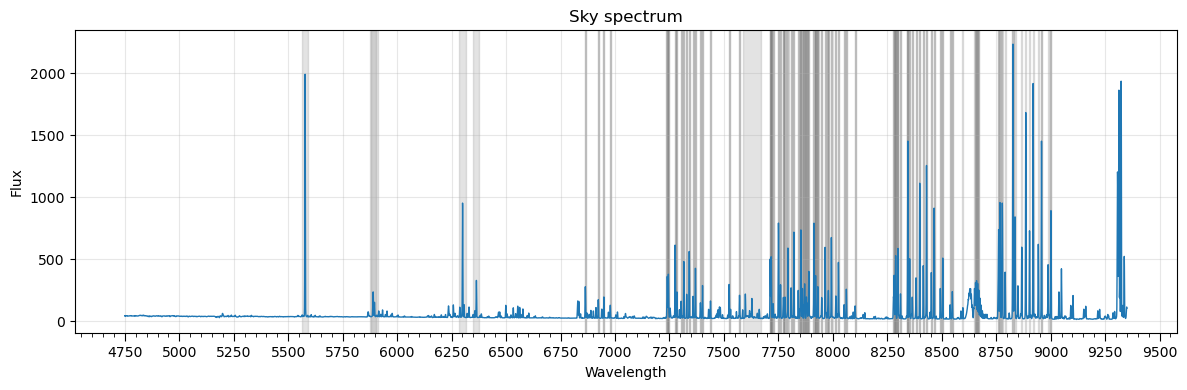

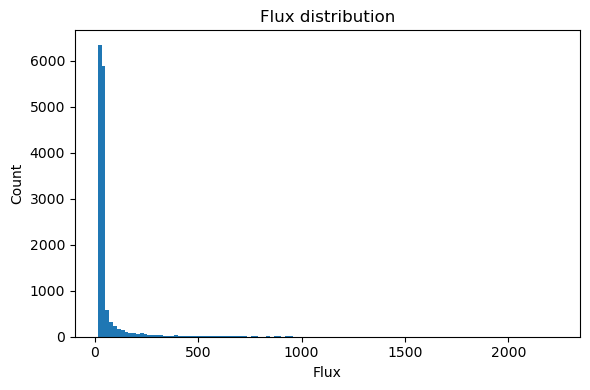

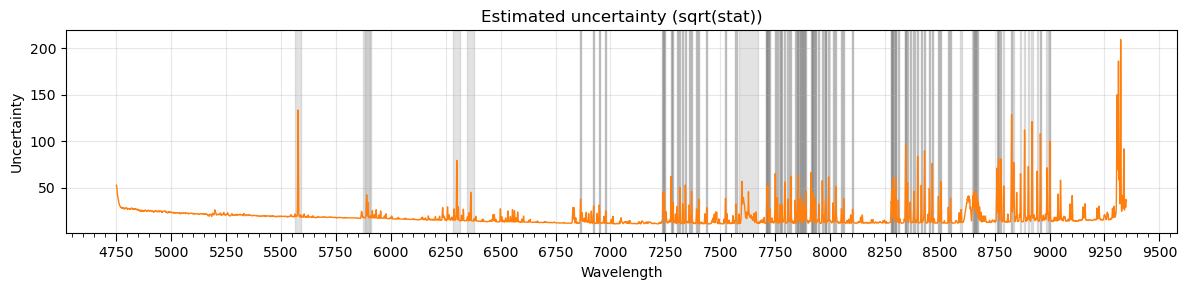


=== DQ SUMMARY ===
DQ=0: 14721 pixels


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from astropy.io import fits


def load_sky_masks(mask_path: Path):
    sky_masks = []

    if not mask_path.exists():
        print(f"Sky mask file not found: {mask_path}")
        return sky_masks

    with mask_path.open() as handle:
        for line_number, raw_line in enumerate(handle, start=1):
            line = raw_line.strip()
            if not line or line.startswith("#"):
                continue

            parts = line.split()
            if len(parts) < 3:
                continue

            try:
                central_wavelength = float(parts[0])
                total_width = float(parts[1])
            except ValueError:
                print(f"Skipping unparsable mask row at line {line_number}: {raw_line.rstrip()}")
                continue

            comment = parts[2].lower()
            if comment == "sky":
                half_width = total_width / 2.0
                sky_masks.append((
                    central_wavelength - half_width,
                    central_wavelength + half_width,
                    central_wavelength,
                    total_width,
                ))

    return sky_masks


def add_sky_mask_bands(ax, sky_masks, wave_values):
    if len(wave_values) == 0 or not sky_masks:
        return 0

    wave_min = np.nanmin(wave_values)
    wave_max = np.nanmax(wave_values)
    bands_drawn = 0

    for left_edge, right_edge, _, _ in sky_masks:
        if right_edge < wave_min or left_edge > wave_max:
            continue
        ax.axvspan(left_edge, right_edge, color="gray", alpha=0.22, zorder=0)
        bands_drawn += 1

    return bands_drawn


def configure_wavelength_ticks(ax, wave_min, wave_max):
    span = wave_max - wave_min
    if span <= 800:
        major_step = 50.0
        minor_step = 10.0
    elif span <= 2000:
        major_step = 100.0
        minor_step = 20.0
    else:
        major_step = 250.0
        minor_step = 50.0

    first_tick = np.floor(wave_min / major_step) * major_step
    last_tick = np.ceil(wave_max / major_step) * major_step
    ax.set_xticks(np.arange(first_tick, last_tick + major_step, major_step))
    ax.xaxis.set_minor_locator(MultipleLocator(minor_step))
    ax.tick_params(axis="x", which="major", length=6)
    ax.tick_params(axis="x", which="minor", length=3)


fits_path = Path.cwd() / "SKY_SPECTRUM_2023-01-18T07_13_15_0001.fits"
mask_path = Path.cwd() / "specMask_KIN"
sky_masks = load_sky_masks(mask_path)

print(f"FITS path: {fits_path}")
print(f"Exists: {fits_path.exists()}")
print(f"Sky mask path: {mask_path}")
print(f"Sky masks loaded: {len(sky_masks)}")

with fits.open(fits_path) as hdul:
    print("\n=== HDU LIST ===")
    hdul.info()

    print("\n=== PRIMARY HEADER (first 30 keys) ===")
    hdr = hdul[0].header
    for i, key in enumerate(hdr.keys()):
        if i >= 30:
            break
        print(f"{key:>10} : {hdr[key]}")

    # Choose first HDU with data; fallback to primary
    data_hdu_idx = None
    for i, hdu in enumerate(hdul):
        if getattr(hdu, "data", None) is not None:
            data_hdu_idx = i
            break
    if data_hdu_idx is None:
        data_hdu_idx = 0

    data = hdul[data_hdu_idx].data

print(f"\nUsing HDU index: {data_hdu_idx}")
print(f"Raw data type: {type(data)}")
print(f"Raw data dtype: {None if data is None else data.dtype}")
print(f"Raw data shape: {None if data is None else data.shape}")

if data is None:
    raise ValueError("No array data found in any HDU.")

# Handle FITS binary tables (structured arrays) vs plain numeric images
if hasattr(data, "names") and data.names is not None:
    print("\n=== TABLE COLUMNS ===")
    print(data.names)

    # Prefer common column names
    wave_col = None
    flux_col = None
    stat_col = None
    dq_col = None

    for name in data.names:
        low = name.lower()
        if wave_col is None and low in ("lambda", "wave", "wavelength", "lam"):
            wave_col = name
        if flux_col is None and low in ("data", "flux", "spec", "spectrum"):
            flux_col = name
        if stat_col is None and low in ("stat", "var", "variance", "err", "error"):
            stat_col = name
        if dq_col is None and low in ("dq", "mask", "quality", "flag"):
            dq_col = name

    if wave_col is None and len(data.names) >= 1:
        wave_col = data.names[0]
    if flux_col is None and len(data.names) >= 2:
        flux_col = data.names[1]
    elif flux_col is None and len(data.names) >= 1:
        flux_col = data.names[0]

    wave = np.asarray(data[wave_col], dtype=float) if wave_col else np.arange(len(data), dtype=float)
    flux = np.asarray(data[flux_col], dtype=float)
    stat = np.asarray(data[stat_col], dtype=float) if stat_col else None
    dq = np.asarray(data[dq_col]) if dq_col else None

    finite = np.isfinite(wave) & np.isfinite(flux)
    wave_f = wave[finite]
    flux_f = flux[finite]

    print("\n=== SELECTED COLUMNS ===")
    print(f"Wavelength column: {wave_col}")
    print(f"Flux column: {flux_col}")
    print(f"Stat column: {stat_col}")
    print(f"DQ column: {dq_col}")

    print("\n=== FLUX STATS (finite values) ===")
    print(f"Total rows: {len(flux)}")
    print(f"Finite rows: {len(flux_f)}")
    if len(flux_f) > 0:
        print(f"Flux min / max: {flux_f.min():.6g} / {flux_f.max():.6g}")
        print(f"Flux mean / std: {flux_f.mean():.6g} / {flux_f.std():.6g}")

    fig, ax = plt.subplots(figsize=(12, 4))
    visible_sky_masks = add_sky_mask_bands(ax, sky_masks, wave_f)
    ax.plot(wave_f, flux_f, lw=1, color="tab:blue")
    ax.set_title("Sky spectrum")
    ax.set_xlabel("Wavelength")
    ax.set_ylabel("Flux")
    configure_wavelength_ticks(ax, np.nanmin(wave_f), np.nanmax(wave_f))
    ax.grid(alpha=0.3)
    print(f"Sky mask bands overlapping the spectrum range: {visible_sky_masks}")
    fig.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.hist(flux_f, bins=120)
    plt.title("Flux distribution")
    plt.xlabel("Flux")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    if stat is not None:
        stat_f = stat[finite]
        err_f = np.sqrt(np.clip(stat_f, 0, None))
        fig, ax = plt.subplots(figsize=(12, 3))
        add_sky_mask_bands(ax, sky_masks, wave_f)
        ax.plot(wave_f, err_f, lw=1, color="tab:orange")
        ax.set_title("Estimated uncertainty (sqrt(stat))")
        ax.set_xlabel("Wavelength")
        ax.set_ylabel("Uncertainty")
        configure_wavelength_ticks(ax, np.nanmin(wave_f), np.nanmax(wave_f))
        ax.grid(alpha=0.3)
        fig.tight_layout()
        plt.show()

    if dq is not None:
        unique_dq, counts_dq = np.unique(dq, return_counts=True)
        print("\n=== DQ SUMMARY ===")
        for v, c in zip(unique_dq, counts_dq):
            print(f"DQ={v}: {c} pixels")

else:
    arr = np.asarray(data, dtype=float)
    finite_vals = arr[np.isfinite(arr)]

    print("\n=== DATA STATS ===")
    print(f"Total elements: {arr.size}")
    print(f"Finite elements: {finite_vals.size}")
    if finite_vals.size > 0:
        print(f"Min / Max: {finite_vals.min():.6g} / {finite_vals.max():.6g}")
        print(f"Mean / Std: {finite_vals.mean():.6g} / {finite_vals.std():.6g}")

    if arr.ndim == 1:
        x = np.arange(arr.shape[0])
        plt.figure(figsize=(12, 4))
        plt.plot(x, arr, lw=1)
        plt.title("1D data")
        plt.xlabel("Pixel index")
        plt.ylabel("Value")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    elif arr.ndim >= 2:
        image = arr[0] if arr.ndim > 2 else arr
        vmin, vmax = np.nanpercentile(image, [5, 95]) if np.isfinite(image).any() else (None, None)
        plt.figure(figsize=(7, 5))
        plt.imshow(image, origin="lower", aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax)
        plt.colorbar(label="Value")
        plt.title(f"Quick-look image from HDU {data_hdu_idx}")
        plt.tight_layout()
        plt.show()

In [2]:
stats_wave_min = 4750.0
stats_wave_max = 5550.0
stats_window = (
    np.isfinite(wave_f)
    & np.isfinite(flux_f)
    & (wave_f >= stats_wave_min)
    & (wave_f <= stats_wave_max)
)

flux_stats = flux_f[stats_window]

if flux_stats.size == 0:
    raise ValueError(
        f"No spectrum samples found between {stats_wave_min} and {stats_wave_max} Angstrom."
    )

print(f"Wavelength window: {stats_wave_min:.0f}-{stats_wave_max:.0f} Angstrom")
print(f"Initial sample count: {flux_stats.size}")
print("\nBefore 3-sigma clip:")
print(f"Mean   = {np.mean(flux_stats):.6f}")
print(f"Median = {np.median(flux_stats):.6f}")
print(f"Std    = {np.std(flux_stats):.6f}")

clipped_flux = flux_stats.copy()
for _ in range(10):
    current_mean = np.mean(clipped_flux)
    current_std = np.std(clipped_flux)
    if current_std == 0:
        break

    keep = np.abs(clipped_flux - current_mean) <= 3.0 * current_std
    if keep.all():
        break
    clipped_flux = clipped_flux[keep]

print("\nAfter 3-sigma clip:")
print(f"Remaining sample count: {clipped_flux.size}")
print(f"Mean   = {np.mean(clipped_flux):.6f}")
print(f"Median = {np.median(clipped_flux):.6f}")
print(f"Std    = {np.std(clipped_flux):.6f}")

Wavelength window: 4750-5550 Angstrom
Initial sample count: 2561

Before 3-sigma clip:
Mean   = 40.135219
Median = 39.773451
Std    = 3.351131

After 3-sigma clip:
Remaining sample count: 2532
Mean   = 40.037858
Median = 39.767997
Std    = 2.965528


In [3]:
stats_wave_min = 7060.0
stats_wave_max = 7110.0
stats_window = (
    np.isfinite(wave_f)
    & np.isfinite(flux_f)
    & (wave_f >= stats_wave_min)
    & (wave_f <= stats_wave_max)
)

flux_stats = flux_f[stats_window]

if flux_stats.size == 0:
    raise ValueError(
        f"No spectrum samples found between {stats_wave_min} and {stats_wave_max} Angstrom."
    )

print(f"Wavelength window: {stats_wave_min:.0f}-{stats_wave_max:.0f} Angstrom")
print(f"Initial sample count: {flux_stats.size}")
print("\nBefore 3-sigma clip:")
print(f"Mean   = {np.mean(flux_stats):.6f}")
print(f"Median = {np.median(flux_stats):.6f}")
print(f"Std    = {np.std(flux_stats):.6f}")

clipped_flux = flux_stats.copy()
for _ in range(10):
    current_mean = np.mean(clipped_flux)
    current_std = np.std(clipped_flux)
    if current_std == 0:
        break

    keep = np.abs(clipped_flux - current_mean) <= 3.0 * current_std
    if keep.all():
        break
    clipped_flux = clipped_flux[keep]

print("\nAfter 3-sigma clip:")
print(f"Remaining sample count: {clipped_flux.size}")
print(f"Mean   = {np.mean(clipped_flux):.6f}")
print(f"Median = {np.median(clipped_flux):.6f}")
print(f"Std    = {np.std(clipped_flux):.6f}")

Wavelength window: 7060-7110 Angstrom
Initial sample count: 161

Before 3-sigma clip:
Mean   = 29.236304
Median = 28.602439
Std    = 4.513099

After 3-sigma clip:
Remaining sample count: 161
Mean   = 29.236304
Median = 28.602439
Std    = 4.513099


Sky mask bands in 6800-7500 Angstrom: 36


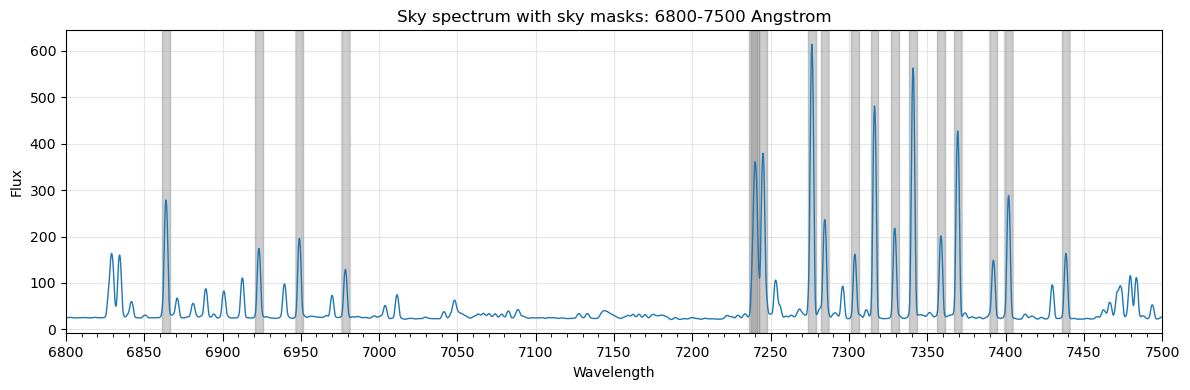

In [4]:
wave_min = 6800.0
wave_max = 7500.0
window = (wave_f >= wave_min) & (wave_f <= wave_max)

if not np.any(window):
    raise ValueError(f"No spectrum samples found between {wave_min} and {wave_max} Angstrom.")

wave_zoom = wave_f[window]
flux_zoom = flux_f[window]

fig, ax = plt.subplots(figsize=(12, 4))
visible_zoom_masks = add_sky_mask_bands(ax, sky_masks, wave_zoom)
ax.plot(wave_zoom, flux_zoom, lw=1, color="tab:blue")
ax.set_xlim(wave_min, wave_max)
ax.set_title("Sky spectrum with sky masks: 6800-7500 Angstrom")
ax.set_xlabel("Wavelength")
ax.set_ylabel("Flux")
configure_wavelength_ticks(ax, wave_min, wave_max)
ax.grid(alpha=0.3)
print(f"Sky mask bands in 6800-7500 Angstrom: {visible_zoom_masks}")
fig.tight_layout()
plt.show()

Sky mask bands in 7500-8200 Angstrom: 78


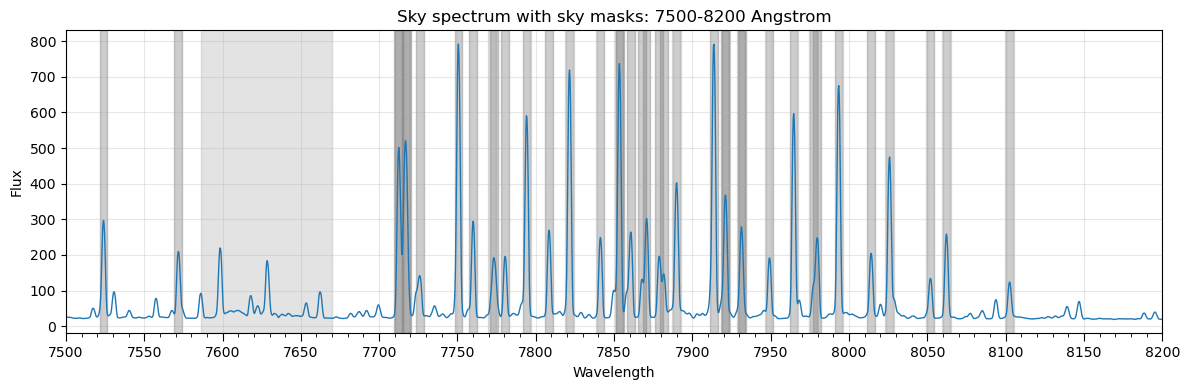

In [5]:
wave_min = 7500.0
wave_max = 8200.0
window = (wave_f >= wave_min) & (wave_f <= wave_max)

if not np.any(window):
    raise ValueError(f"No spectrum samples found between {wave_min} and {wave_max} Angstrom.")

wave_zoom = wave_f[window]
flux_zoom = flux_f[window]

fig, ax = plt.subplots(figsize=(12, 4))
visible_zoom_masks = add_sky_mask_bands(ax, sky_masks, wave_zoom)
ax.plot(wave_zoom, flux_zoom, lw=1, color="tab:blue")
ax.set_xlim(wave_min, wave_max)
ax.set_title("Sky spectrum with sky masks: 7500-8200 Angstrom")
ax.set_xlabel("Wavelength")
ax.set_ylabel("Flux")
configure_wavelength_ticks(ax, wave_min, wave_max)
ax.grid(alpha=0.3)
print(f"Sky mask bands in 7500-8200 Angstrom: {visible_zoom_masks}")
fig.tight_layout()
plt.show()

Sky mask bands in 8200-9200 Angstrom: 72


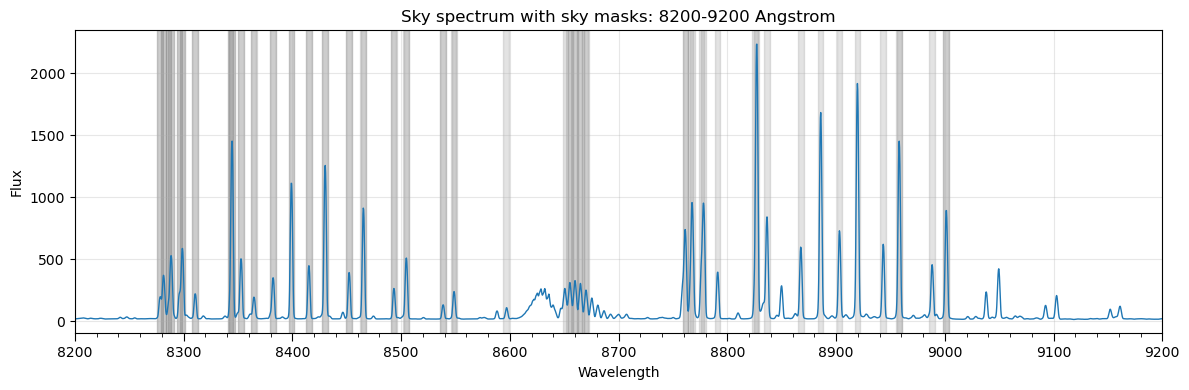

In [6]:
wave_min = 8200.0
wave_max = 9200.0
window = (wave_f >= wave_min) & (wave_f <= wave_max)

if not np.any(window):
    raise ValueError(f"No spectrum samples found between {wave_min} and {wave_max} Angstrom.")

wave_zoom = wave_f[window]
flux_zoom = flux_f[window]

fig, ax = plt.subplots(figsize=(12, 4))
visible_zoom_masks = add_sky_mask_bands(ax, sky_masks, wave_zoom)
ax.plot(wave_zoom, flux_zoom, lw=1, color="tab:blue")
ax.set_xlim(wave_min, wave_max)
ax.set_title("Sky spectrum with sky masks: 8200-9200 Angstrom")
ax.set_xlabel("Wavelength")
ax.set_ylabel("Flux")
configure_wavelength_ticks(ax, wave_min, wave_max)
ax.grid(alpha=0.3)
print(f"Sky mask bands in 8200-9200 Angstrom: {visible_zoom_masks}")
fig.tight_layout()
plt.show()

## determine the peak of the sky spectrum (Flux>=50)

Detected peaks for wavelength >= 6800 Angstrom and flux >= 100: 118
Strongest peak: wavelength = 8827.19 Angstrom, flux = 2235.55

Peak list (wavelength, flux):
  6829.06      163.56
  6834.38      160.09
  6863.75      278.61
  6912.81      110.47
  6923.12      174.16
  6949.06      196.04
  6978.44      129.25
  7240.00      360.88
  7245.00      379.42
  7253.12      106.19
  7276.25      614.32
  7284.69      236.13
  7303.75      161.76
  7316.25      481.05
  7329.06      217.44
  7340.94      562.83
  7358.75      201.31
  7369.38      427.10
  7392.19      148.80
  7401.88      288.30
  7438.44      163.34
  7479.69      115.58
  7483.44      111.77
  7524.06      297.03
  7571.88      209.51
  7598.44      219.51
  7628.44      183.75
  7712.50      501.50
  7716.88      520.31
  7725.94      141.82
  7750.62      791.75
  7760.00      294.20
  7773.12      192.07
  7780.31      195.28
  7794.06      590.44
  7808.44      269.49
  7821.56      719.00
  7841.25      248.77
  7

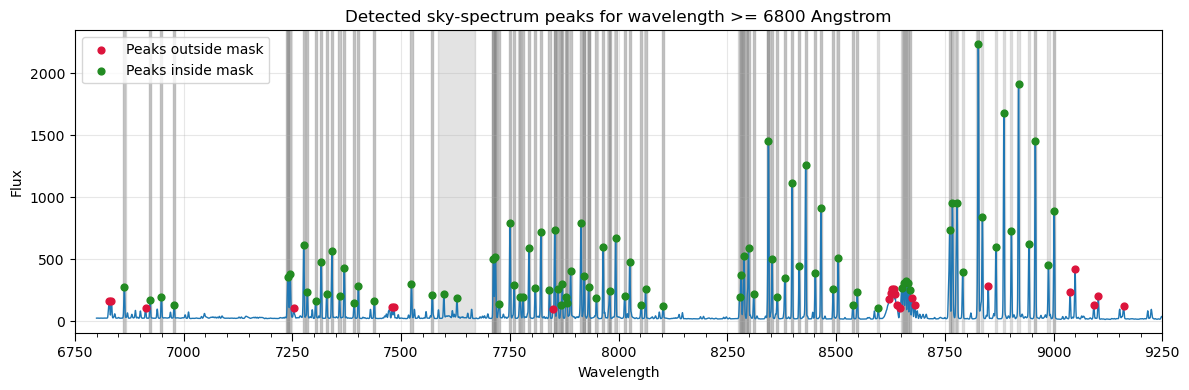

In [7]:
peak_wave_min = 6800.0
peak_flux_min = 100.0
peak_window = np.isfinite(wave_f) & np.isfinite(flux_f) & (wave_f >= peak_wave_min)

wave_peak = wave_f[peak_window]
flux_peak = flux_f[peak_window]

if wave_peak.size < 3:
    raise ValueError("Not enough samples to detect peaks in the selected wavelength range.")

interior = np.arange(1, flux_peak.size - 1)
peak_mask = (
    (flux_peak[1:-1] >= peak_flux_min)
    & (flux_peak[1:-1] > flux_peak[:-2])
    & (flux_peak[1:-1] >= flux_peak[2:])
)
peak_indices = interior[peak_mask]
peak_wavelengths = wave_peak[peak_indices]
peak_fluxes = flux_peak[peak_indices]

sort_order = np.argsort(peak_wavelengths)
peak_wavelengths = peak_wavelengths[sort_order]
peak_fluxes = peak_fluxes[sort_order]

print(f"Detected peaks for wavelength >= {peak_wave_min:.0f} Angstrom and flux >= {peak_flux_min:.0f}: {peak_wavelengths.size}")

if peak_wavelengths.size == 0:
    print("No peaks satisfy the selection criteria.")
else:
    strongest_index = np.argmax(peak_fluxes)
    print(
        f"Strongest peak: wavelength = {peak_wavelengths[strongest_index]:.2f} Angstrom, "
        f"flux = {peak_fluxes[strongest_index]:.2f}"
    )
    print("\nPeak list (wavelength, flux):")
    for wavelength, flux_value in zip(peak_wavelengths, peak_fluxes):
        print(f"{wavelength:9.2f}  {flux_value:10.2f}")

fig, ax = plt.subplots(figsize=(12, 4))
add_sky_mask_bands(ax, sky_masks, wave_peak)
ax.plot(wave_peak, flux_peak, lw=1, color="tab:blue")
if peak_wavelengths.size > 0:
    peak_in_mask = np.array([
        any(left_edge <= wavelength <= right_edge for left_edge, right_edge, _, _ in sky_masks)
        for wavelength in peak_wavelengths
    ])
    if np.any(~peak_in_mask):
        ax.scatter(
            peak_wavelengths[~peak_in_mask],
            peak_fluxes[~peak_in_mask],
            color="crimson",
            s=24,
            zorder=3,
            label="Peaks outside mask",
        )
    if np.any(peak_in_mask):
        ax.scatter(
            peak_wavelengths[peak_in_mask],
            peak_fluxes[peak_in_mask],
            color="forestgreen",
            s=24,
            zorder=3,
            label="Peaks inside mask",
        )
    ax.legend()
ax.set_xlim(peak_wave_min, 9250)
ax.set_title("Detected sky-spectrum peaks for wavelength >= 6800 Angstrom")
ax.set_xlabel("Wavelength")
ax.set_ylabel("Flux")
configure_wavelength_ticks(ax, peak_wave_min, 9250)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

Detected peaks for 6800-7500 Angstrom and flux >= 100: 23
Strongest peak: wavelength = 7276.25 Angstrom, flux = 614.32

Peak list (wavelength, flux):
  6829.06      163.56
  6834.38      160.09
  6863.75      278.61
  6912.81      110.47
  6923.12      174.16
  6949.06      196.04
  6978.44      129.25
  7240.00      360.88
  7245.00      379.42
  7253.12      106.19
  7276.25      614.32
  7284.69      236.13
  7303.75      161.76
  7316.25      481.05
  7329.06      217.44
  7340.94      562.83
  7358.75      201.31
  7369.38      427.10
  7392.19      148.80
  7401.88      288.30
  7438.44      163.34
  7479.69      115.58
  7483.44      111.77


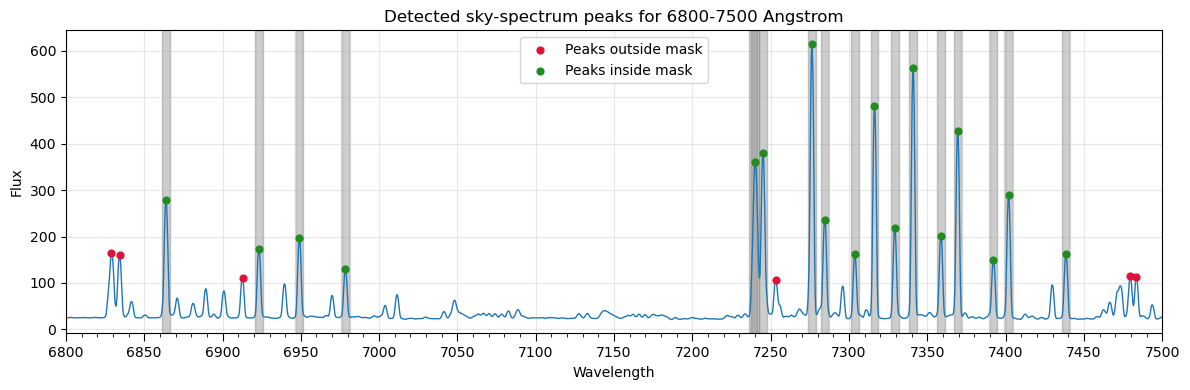

In [8]:
peak_wave_min = 6800.0
peak_wave_max = 7500.0
peak_flux_min = 100.0
peak_window = (
    np.isfinite(wave_f)
    & np.isfinite(flux_f)
    & (wave_f >= peak_wave_min)
    & (wave_f <= peak_wave_max)
)

wave_peak = wave_f[peak_window]
flux_peak = flux_f[peak_window]

if wave_peak.size < 3:
    raise ValueError("Not enough samples to detect peaks in the selected wavelength range.")

interior = np.arange(1, flux_peak.size - 1)
peak_mask = (
    (flux_peak[1:-1] >= peak_flux_min)
    & (flux_peak[1:-1] > flux_peak[:-2])
    & (flux_peak[1:-1] >= flux_peak[2:])
)
peak_indices = interior[peak_mask]
peak_wavelengths = wave_peak[peak_indices]
peak_fluxes = flux_peak[peak_indices]

sort_order = np.argsort(peak_wavelengths)
peak_wavelengths = peak_wavelengths[sort_order]
peak_fluxes = peak_fluxes[sort_order]

print(
    f"Detected peaks for {peak_wave_min:.0f}-{peak_wave_max:.0f} Angstrom "
    f"and flux >= {peak_flux_min:.0f}: {peak_wavelengths.size}"
)

if peak_wavelengths.size == 0:
    print("No peaks satisfy the selection criteria.")
else:
    strongest_index = np.argmax(peak_fluxes)
    print(
        f"Strongest peak: wavelength = {peak_wavelengths[strongest_index]:.2f} Angstrom, "
        f"flux = {peak_fluxes[strongest_index]:.2f}"
    )
    print("\nPeak list (wavelength, flux):")
    for wavelength, flux_value in zip(peak_wavelengths, peak_fluxes):
        print(f"{wavelength:9.2f}  {flux_value:10.2f}")

fig, ax = plt.subplots(figsize=(12, 4))
add_sky_mask_bands(ax, sky_masks, wave_peak)
ax.plot(wave_peak, flux_peak, lw=1, color="tab:blue")
if peak_wavelengths.size > 0:
    peak_in_mask = np.array([
        any(left_edge <= wavelength <= right_edge for left_edge, right_edge, _, _ in sky_masks)
        for wavelength in peak_wavelengths
    ])
    if np.any(~peak_in_mask):
        ax.scatter(
            peak_wavelengths[~peak_in_mask],
            peak_fluxes[~peak_in_mask],
            color="crimson",
            s=24,
            zorder=3,
            label="Peaks outside mask",
        )
    if np.any(peak_in_mask):
        ax.scatter(
            peak_wavelengths[peak_in_mask],
            peak_fluxes[peak_in_mask],
            color="forestgreen",
            s=24,
            zorder=3,
            label="Peaks inside mask",
        )
    ax.legend()
ax.set_xlim(peak_wave_min, peak_wave_max)
ax.set_title("Detected sky-spectrum peaks for 6800-7500 Angstrom")
ax.set_xlabel("Wavelength")
ax.set_ylabel("Flux")
configure_wavelength_ticks(ax, peak_wave_min, peak_wave_max)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

Detected peaks for 7500-8200 Angstrom and flux >= 100: 35
Strongest peak: wavelength = 7750.62 Angstrom, flux = 791.75

Peak list (wavelength, flux):
  7524.06      297.03
  7571.88      209.51
  7598.44      219.51
  7628.44      183.75
  7712.50      501.50
  7716.88      520.31
  7725.94      141.82
  7750.62      791.75
  7760.00      294.20
  7773.12      192.07
  7780.31      195.28
  7794.06      590.44
  7808.44      269.49
  7821.56      719.00
  7841.25      248.77
  7850.00      100.58
  7853.44      736.59
  7860.62      264.26
  7867.81      131.87
  7870.62      302.10
  7878.75      196.11
  7881.56      146.54
  7890.00      402.24
  7913.75      791.25
  7920.94      368.11
  7931.25      278.79
  7949.38      191.40
  7964.69      596.31
  7979.69      247.99
  7993.44      675.18
  8014.06      204.15
  8025.94      474.68
  8051.88      133.90
  8062.19      258.40
  8102.50      123.79


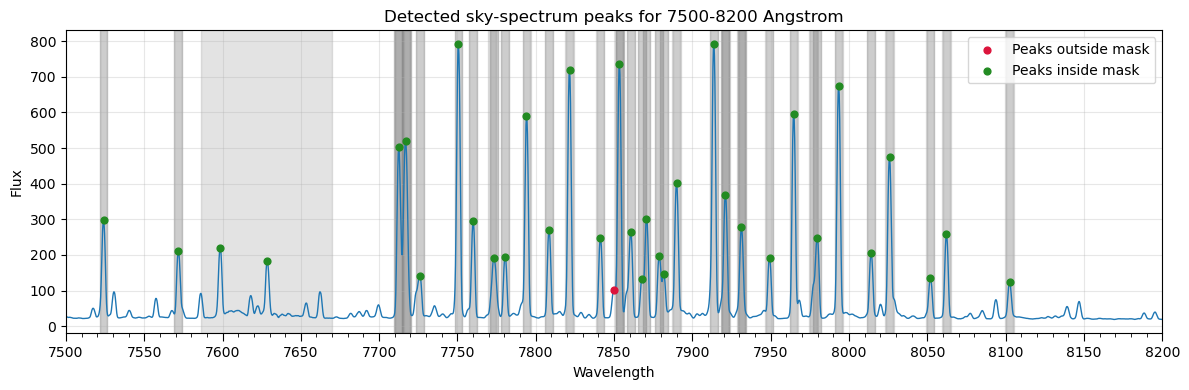

In [9]:
peak_wave_min = 7500.0
peak_wave_max = 8200.0
peak_flux_min = 100.0
peak_window = (
    np.isfinite(wave_f)
    & np.isfinite(flux_f)
    & (wave_f >= peak_wave_min)
    & (wave_f <= peak_wave_max)
)

wave_peak = wave_f[peak_window]
flux_peak = flux_f[peak_window]

if wave_peak.size < 3:
    raise ValueError("Not enough samples to detect peaks in the selected wavelength range.")

interior = np.arange(1, flux_peak.size - 1)
peak_mask = (
    (flux_peak[1:-1] >= peak_flux_min)
    & (flux_peak[1:-1] > flux_peak[:-2])
    & (flux_peak[1:-1] >= flux_peak[2:])
)
peak_indices = interior[peak_mask]
peak_wavelengths = wave_peak[peak_indices]
peak_fluxes = flux_peak[peak_indices]

sort_order = np.argsort(peak_wavelengths)
peak_wavelengths = peak_wavelengths[sort_order]
peak_fluxes = peak_fluxes[sort_order]

print(
    f"Detected peaks for {peak_wave_min:.0f}-{peak_wave_max:.0f} Angstrom "
    f"and flux >= {peak_flux_min:.0f}: {peak_wavelengths.size}"
)

if peak_wavelengths.size == 0:
    print("No peaks satisfy the selection criteria.")
else:
    strongest_index = np.argmax(peak_fluxes)
    print(
        f"Strongest peak: wavelength = {peak_wavelengths[strongest_index]:.2f} Angstrom, "
        f"flux = {peak_fluxes[strongest_index]:.2f}"
    )
    print("\nPeak list (wavelength, flux):")
    for wavelength, flux_value in zip(peak_wavelengths, peak_fluxes):
        print(f"{wavelength:9.2f}  {flux_value:10.2f}")

fig, ax = plt.subplots(figsize=(12, 4))
add_sky_mask_bands(ax, sky_masks, wave_peak)
ax.plot(wave_peak, flux_peak, lw=1, color="tab:blue")
if peak_wavelengths.size > 0:
    peak_in_mask = np.array([
        any(left_edge <= wavelength <= right_edge for left_edge, right_edge, _, _ in sky_masks)
        for wavelength in peak_wavelengths
    ])
    if np.any(~peak_in_mask):
        ax.scatter(
            peak_wavelengths[~peak_in_mask],
            peak_fluxes[~peak_in_mask],
            color="crimson",
            s=24,
            zorder=3,
            label="Peaks outside mask",
        )
    if np.any(peak_in_mask):
        ax.scatter(
            peak_wavelengths[peak_in_mask],
            peak_fluxes[peak_in_mask],
            color="forestgreen",
            s=24,
            zorder=3,
            label="Peaks inside mask",
        )
    ax.legend()
ax.set_xlim(peak_wave_min, peak_wave_max)
ax.set_title("Detected sky-spectrum peaks for 7500-8200 Angstrom")
ax.set_xlabel("Wavelength")
ax.set_ylabel("Flux")
configure_wavelength_ticks(ax, peak_wave_min, peak_wave_max)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

Detected peaks for 8200-9200 Angstrom and flux >= 100: 53
Strongest peak: wavelength = 8827.19 Angstrom, flux = 2235.55

Peak list (wavelength, flux):
  8278.75      198.23
  8281.56      370.73
  8288.44      529.01
  8299.06      587.34
  8310.62      220.99
  8344.69     1453.12
  8352.81      503.71
  8364.69      194.43
  8382.50      350.39
  8399.06     1113.24
  8415.31      447.89
  8430.31     1256.53
  8452.19      392.41
  8465.31      912.64
  8493.44      264.18
  8505.00      509.45
  8538.75      132.76
  8548.75      239.33
  8597.19      109.28
  8622.19      177.02
  8625.31      226.82
  8628.75      261.11
  8632.19      263.36
  8635.94      219.11
  8639.69      130.94
  8647.19      104.74
  8650.62      264.40
  8655.31      311.87
  8660.00      327.72
  8665.00      304.86
  8670.00      251.42
  8675.31      186.45
  8680.94      130.42
  8761.25      739.54
  8767.50      957.35
  8778.12      952.99
  8791.25      396.12
  8827.19     2235.55
  8836.56    

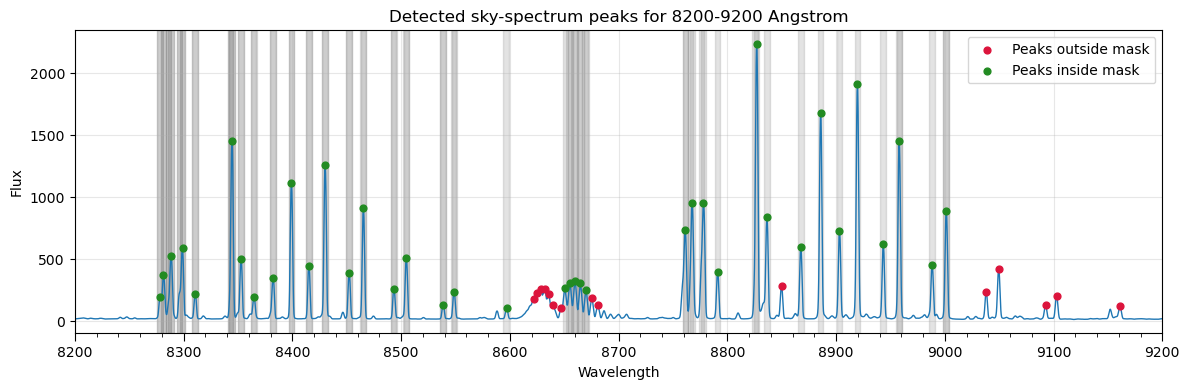

In [10]:
peak_wave_min = 8200.0
peak_wave_max = 9200.0
peak_flux_min = 100.0
peak_window = (
    np.isfinite(wave_f)
    & np.isfinite(flux_f)
    & (wave_f >= peak_wave_min)
    & (wave_f <= peak_wave_max)
)

wave_peak = wave_f[peak_window]
flux_peak = flux_f[peak_window]

if wave_peak.size < 3:
    raise ValueError("Not enough samples to detect peaks in the selected wavelength range.")

interior = np.arange(1, flux_peak.size - 1)
peak_mask = (
    (flux_peak[1:-1] >= peak_flux_min)
    & (flux_peak[1:-1] > flux_peak[:-2])
    & (flux_peak[1:-1] >= flux_peak[2:])
)
peak_indices = interior[peak_mask]
peak_wavelengths = wave_peak[peak_indices]
peak_fluxes = flux_peak[peak_indices]

sort_order = np.argsort(peak_wavelengths)
peak_wavelengths = peak_wavelengths[sort_order]
peak_fluxes = peak_fluxes[sort_order]

print(
    f"Detected peaks for {peak_wave_min:.0f}-{peak_wave_max:.0f} Angstrom "
    f"and flux >= {peak_flux_min:.0f}: {peak_wavelengths.size}"
)

if peak_wavelengths.size == 0:
    print("No peaks satisfy the selection criteria.")
else:
    strongest_index = np.argmax(peak_fluxes)
    print(
        f"Strongest peak: wavelength = {peak_wavelengths[strongest_index]:.2f} Angstrom, "
        f"flux = {peak_fluxes[strongest_index]:.2f}"
    )
    print("\nPeak list (wavelength, flux):")
    for wavelength, flux_value in zip(peak_wavelengths, peak_fluxes):
        print(f"{wavelength:9.2f}  {flux_value:10.2f}")

fig, ax = plt.subplots(figsize=(12, 4))
add_sky_mask_bands(ax, sky_masks, wave_peak)
ax.plot(wave_peak, flux_peak, lw=1, color="tab:blue")
if peak_wavelengths.size > 0:
    peak_in_mask = np.array([
        any(left_edge <= wavelength <= right_edge for left_edge, right_edge, _, _ in sky_masks)
        for wavelength in peak_wavelengths
    ])
    if np.any(~peak_in_mask):
        ax.scatter(
            peak_wavelengths[~peak_in_mask],
            peak_fluxes[~peak_in_mask],
            color="crimson",
            s=24,
            zorder=3,
            label="Peaks outside mask",
        )
    if np.any(peak_in_mask):
        ax.scatter(
            peak_wavelengths[peak_in_mask],
            peak_fluxes[peak_in_mask],
            color="forestgreen",
            s=24,
            zorder=3,
            label="Peaks inside mask",
        )
    ax.legend()
ax.set_xlim(peak_wave_min, peak_wave_max)
ax.set_title("Detected sky-spectrum peaks for 8200-9200 Angstrom")
ax.set_xlabel("Wavelength")
ax.set_ylabel("Flux")
configure_wavelength_ticks(ax, peak_wave_min, peak_wave_max)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## My way to deterimine the spectral masking $\geq 6800\AA$

1. detect all the peaks in the sky spectrum with flux >= 50 at $6800-9200\AA$
2. then we distinguish two groups of peaks: green is already masked by `specMask_KIN`, while red is not masked yet.
3. For green peaks, then use the existing `specMask_KIN` to determine the masking, while for red peaks, use the detected peak wavelength as the center. As for the width, we widen all the $5\AA$ to $6\AA$ (including the exising ones in `specMask_KIN` and the newly detected ones). As for the special `7628.00             84             sky`, update from $84\AA$ to $96\AA$.

Detected peaks for 6800-9200 Angstrom and flux >= 100: 111
Peaks already masked by specMask_KIN: 89
Peaks not yet masked: 22
Existing sky masks in range after width updates: 186
New masks added from red peaks: 22
Total updated masks in range: 208
Strongest peak: wavelength = 8827.19 Angstrom, flux = 2235.55

New mask centers from red peaks:
  6829.06  width=6.00
  6834.38  width=6.00
  6912.81  width=6.00
  7253.12  width=6.00
  7479.69  width=6.00
  7483.44  width=6.00
  7850.00  width=6.00
  8622.19  width=6.00
  8625.31  width=6.00
  8628.75  width=6.00
  8632.19  width=6.00
  8635.94  width=6.00
  8639.69  width=6.00
  8647.19  width=6.00
  8675.31  width=6.00
  8680.94  width=6.00
  8850.00  width=6.00
  9038.12  width=6.00
  9049.69  width=6.00
  9092.81  width=6.00
  9102.81  width=6.00
  9161.25  width=6.00


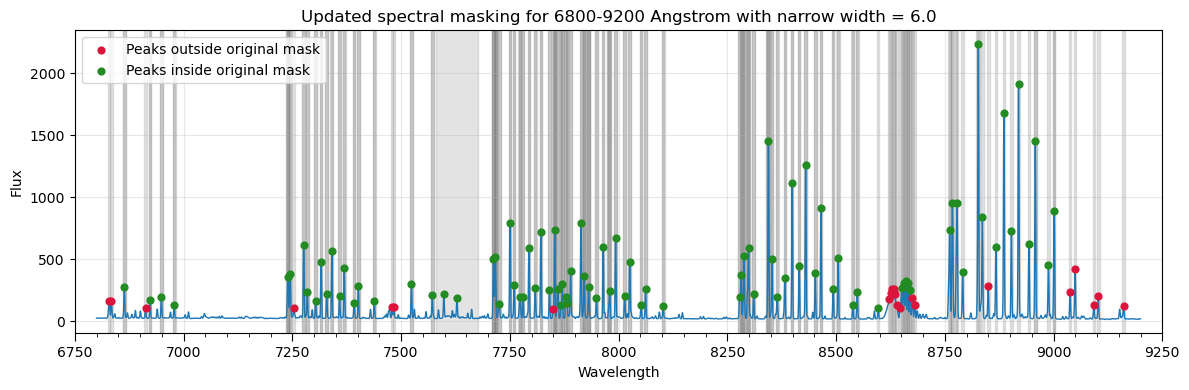

In [11]:
peak_wave_min = 6800.0
peak_wave_max = 9200.0
peak_flux_min = 100.0
updated_narrow_width = 6.0
special_center = 7628.0
special_original_width = 84.0
special_updated_width = 96.0

peak_window = (
    np.isfinite(wave_f)
    & np.isfinite(flux_f)
    & (wave_f >= peak_wave_min)
    & (wave_f <= peak_wave_max)
)

wave_peak = wave_f[peak_window]
flux_peak = flux_f[peak_window]

if wave_peak.size < 3:
    raise ValueError("Not enough samples to detect peaks in the selected wavelength range.")

interior = np.arange(1, flux_peak.size - 1)
peak_mask = (
    (flux_peak[1:-1] >= peak_flux_min)
    & (flux_peak[1:-1] > flux_peak[:-2])
    & (flux_peak[1:-1] >= flux_peak[2:])
)
peak_indices = interior[peak_mask]
peak_wavelengths = wave_peak[peak_indices]
peak_fluxes = flux_peak[peak_indices]

sort_order = np.argsort(peak_wavelengths)
peak_wavelengths = peak_wavelengths[sort_order]
peak_fluxes = peak_fluxes[sort_order]

peak_in_mask = np.array([
    any(left_edge <= wavelength <= right_edge for left_edge, right_edge, _, _ in sky_masks)
    for wavelength in peak_wavelengths
])

def update_existing_mask(mask_entry):
    left_edge, right_edge, center, width = mask_entry
    updated_width = width

    if np.isclose(center, special_center, atol=0.5) and np.isclose(width, special_original_width, atol=0.5):
        updated_width = special_updated_width
    elif np.isclose(width, 5.0, atol=1e-6):
        updated_width = updated_narrow_width

    half_width = updated_width / 2.0
    return (center - half_width, center + half_width, center, updated_width)

existing_masks_in_range = [
    update_existing_mask(mask_entry)
    for mask_entry in sky_masks
    if mask_entry[1] >= peak_wave_min and mask_entry[0] <= peak_wave_max
]

new_red_masks = []
for wavelength in peak_wavelengths[~peak_in_mask]:
    half_width = updated_narrow_width / 2.0
    new_red_masks.append((wavelength - half_width, wavelength + half_width, wavelength, updated_narrow_width))

updated_masks = sorted(existing_masks_in_range + new_red_masks, key=lambda mask_entry: mask_entry[2])

print(
    f"Detected peaks for {peak_wave_min:.0f}-{peak_wave_max:.0f} Angstrom "
    f"and flux >= {peak_flux_min:.0f}: {peak_wavelengths.size}"
)
print(f"Peaks already masked by specMask_KIN: {np.count_nonzero(peak_in_mask)}")
print(f"Peaks not yet masked: {np.count_nonzero(~peak_in_mask)}")
print(f"Existing sky masks in range after width updates: {len(existing_masks_in_range)}")
print(f"New masks added from red peaks: {len(new_red_masks)}")
print(f"Total updated masks in range: {len(updated_masks)}")

if peak_wavelengths.size == 0:
    print("No peaks satisfy the selection criteria.")
else:
    strongest_index = np.argmax(peak_fluxes)
    print(
        f"Strongest peak: wavelength = {peak_wavelengths[strongest_index]:.2f} Angstrom, "
        f"flux = {peak_fluxes[strongest_index]:.2f}"
    )

    if new_red_masks:
        print("\nNew mask centers from red peaks:")
        for _, _, wavelength, width in new_red_masks:
            print(f"{wavelength:9.2f}  width={width:.2f}")

fig, ax = plt.subplots(figsize=(12, 4))
add_sky_mask_bands(ax, updated_masks, wave_peak)
ax.plot(wave_peak, flux_peak, lw=1, color="tab:blue")
if peak_wavelengths.size > 0:
    if np.any(~peak_in_mask):
        ax.scatter(
            peak_wavelengths[~peak_in_mask],
            peak_fluxes[~peak_in_mask],
            color="crimson",
            s=24,
            zorder=3,
            label="Peaks outside original mask",
        )
    if np.any(peak_in_mask):
        ax.scatter(
            peak_wavelengths[peak_in_mask],
            peak_fluxes[peak_in_mask],
            color="forestgreen",
            s=24,
            zorder=3,
            label="Peaks inside original mask",
        )
    ax.legend()
ax.set_xlim(peak_wave_min, peak_wave_max)
ax.set_title(f"Updated spectral masking for 6800-9200 Angstrom with narrow width = {updated_narrow_width}")
ax.set_xlabel("Wavelength")
ax.set_ylabel("Flux")
configure_wavelength_ticks(ax, peak_wave_min, peak_wave_max)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

Detected peaks for 6800-7500 Angstrom and flux >= 100: 23
Peaks already masked by specMask_KIN: 17
Peaks not yet masked: 6
Existing sky masks in range after width updates: 36
New masks added from red peaks: 6
Total updated masks in range: 42
Strongest peak: wavelength = 7276.25 Angstrom, flux = 614.32

New mask centers from red peaks:
  6829.06  width=6.00
  6834.38  width=6.00
  6912.81  width=6.00
  7253.12  width=6.00
  7479.69  width=6.00
  7483.44  width=6.00


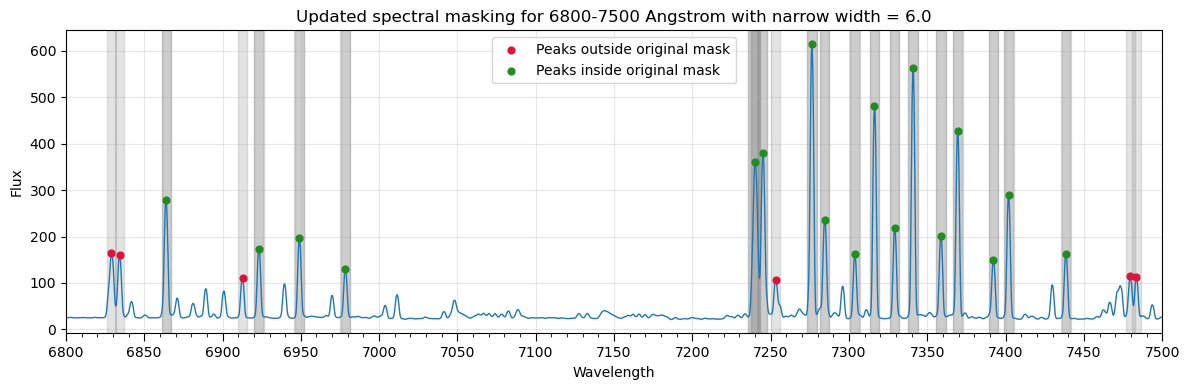

In [12]:
peak_wave_min = 6800.0
peak_wave_max = 7500.0
peak_flux_min = 100.0
updated_narrow_width = 6.0
special_center = 7628.0
special_original_width = 84.0
special_updated_width = 96.0

peak_window = (
    np.isfinite(wave_f)
    & np.isfinite(flux_f)
    & (wave_f >= peak_wave_min)
    & (wave_f <= peak_wave_max)
)

wave_peak = wave_f[peak_window]
flux_peak = flux_f[peak_window]

if wave_peak.size < 3:
    raise ValueError("Not enough samples to detect peaks in the selected wavelength range.")

interior = np.arange(1, flux_peak.size - 1)
peak_mask = (
    (flux_peak[1:-1] >= peak_flux_min)
    & (flux_peak[1:-1] > flux_peak[:-2])
    & (flux_peak[1:-1] >= flux_peak[2:])
)
peak_indices = interior[peak_mask]
peak_wavelengths = wave_peak[peak_indices]
peak_fluxes = flux_peak[peak_indices]

sort_order = np.argsort(peak_wavelengths)
peak_wavelengths = peak_wavelengths[sort_order]
peak_fluxes = peak_fluxes[sort_order]

peak_in_mask = np.array([
    any(left_edge <= wavelength <= right_edge for left_edge, right_edge, _, _ in sky_masks)
    for wavelength in peak_wavelengths
])

def update_existing_mask(mask_entry):
    left_edge, right_edge, center, width = mask_entry
    updated_width = width

    if np.isclose(center, special_center, atol=0.5) and np.isclose(width, special_original_width, atol=0.5):
        updated_width = special_updated_width
    elif np.isclose(width, 5.0, atol=1e-6):
        updated_width = updated_narrow_width

    half_width = updated_width / 2.0
    return (center - half_width, center + half_width, center, updated_width)

existing_masks_in_range = [
    update_existing_mask(mask_entry)
    for mask_entry in sky_masks
    if mask_entry[1] >= peak_wave_min and mask_entry[0] <= peak_wave_max
]

new_red_masks = []
for wavelength in peak_wavelengths[~peak_in_mask]:
    half_width = updated_narrow_width / 2.0
    new_red_masks.append((wavelength - half_width, wavelength + half_width, wavelength, updated_narrow_width))

updated_masks = sorted(existing_masks_in_range + new_red_masks, key=lambda mask_entry: mask_entry[2])

print(
    f"Detected peaks for {peak_wave_min:.0f}-{peak_wave_max:.0f} Angstrom "
    f"and flux >= {peak_flux_min:.0f}: {peak_wavelengths.size}"
)
print(f"Peaks already masked by specMask_KIN: {np.count_nonzero(peak_in_mask)}")
print(f"Peaks not yet masked: {np.count_nonzero(~peak_in_mask)}")
print(f"Existing sky masks in range after width updates: {len(existing_masks_in_range)}")
print(f"New masks added from red peaks: {len(new_red_masks)}")
print(f"Total updated masks in range: {len(updated_masks)}")

if peak_wavelengths.size == 0:
    print("No peaks satisfy the selection criteria.")
else:
    strongest_index = np.argmax(peak_fluxes)
    print(
        f"Strongest peak: wavelength = {peak_wavelengths[strongest_index]:.2f} Angstrom, "
        f"flux = {peak_fluxes[strongest_index]:.2f}"
    )

    if new_red_masks:
        print("\nNew mask centers from red peaks:")
        for _, _, wavelength, width in new_red_masks:
            print(f"{wavelength:9.2f}  width={width:.2f}")

fig, ax = plt.subplots(figsize=(12, 4))
add_sky_mask_bands(ax, updated_masks, wave_peak)
ax.plot(wave_peak, flux_peak, lw=1, color="tab:blue")
if peak_wavelengths.size > 0:
    if np.any(~peak_in_mask):
        ax.scatter(
            peak_wavelengths[~peak_in_mask],
            peak_fluxes[~peak_in_mask],
            color="crimson",
            s=24,
            zorder=3,
            label="Peaks outside original mask",
        )
    if np.any(peak_in_mask):
        ax.scatter(
            peak_wavelengths[peak_in_mask],
            peak_fluxes[peak_in_mask],
            color="forestgreen",
            s=24,
            zorder=3,
            label="Peaks inside original mask",
        )
    ax.legend()
ax.set_xlim(peak_wave_min, peak_wave_max)
ax.set_title(f"Updated spectral masking for 6800-7500 Angstrom with narrow width = {updated_narrow_width}")
ax.set_xlabel("Wavelength")
ax.set_ylabel("Flux")
configure_wavelength_ticks(ax, peak_wave_min, peak_wave_max)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

Detected peaks for 7500-8200 Angstrom and flux >= 100: 35
Peaks already masked by specMask_KIN: 34
Peaks not yet masked: 1
Existing sky masks in range after width updates: 78
New masks added from red peaks: 1
Total updated masks in range: 79
Strongest peak: wavelength = 7750.62 Angstrom, flux = 791.75

New mask centers from red peaks:
  7850.00  width=6.00


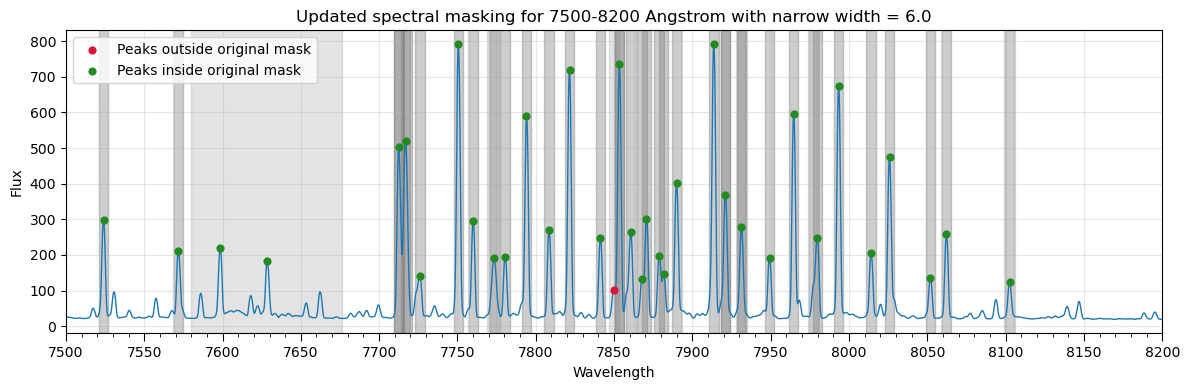

In [13]:
peak_wave_min = 7500.0
peak_wave_max = 8200.0
peak_flux_min = 100.0
updated_narrow_width = 6.0
special_center = 7628.0
special_original_width = 84.0
special_updated_width = 96.0

peak_window = (
    np.isfinite(wave_f)
    & np.isfinite(flux_f)
    & (wave_f >= peak_wave_min)
    & (wave_f <= peak_wave_max)
)

wave_peak = wave_f[peak_window]
flux_peak = flux_f[peak_window]

if wave_peak.size < 3:
    raise ValueError("Not enough samples to detect peaks in the selected wavelength range.")

interior = np.arange(1, flux_peak.size - 1)
peak_mask = (
    (flux_peak[1:-1] >= peak_flux_min)
    & (flux_peak[1:-1] > flux_peak[:-2])
    & (flux_peak[1:-1] >= flux_peak[2:])
)
peak_indices = interior[peak_mask]
peak_wavelengths = wave_peak[peak_indices]
peak_fluxes = flux_peak[peak_indices]

sort_order = np.argsort(peak_wavelengths)
peak_wavelengths = peak_wavelengths[sort_order]
peak_fluxes = peak_fluxes[sort_order]

peak_in_mask = np.array([
    any(left_edge <= wavelength <= right_edge for left_edge, right_edge, _, _ in sky_masks)
    for wavelength in peak_wavelengths
])

def update_existing_mask(mask_entry):
    left_edge, right_edge, center, width = mask_entry
    updated_width = width

    if np.isclose(center, special_center, atol=0.5) and np.isclose(width, special_original_width, atol=0.5):
        updated_width = special_updated_width
    elif np.isclose(width, 5.0, atol=1e-6):
        updated_width = updated_narrow_width

    half_width = updated_width / 2.0
    return (center - half_width, center + half_width, center, updated_width)

existing_masks_in_range = [
    update_existing_mask(mask_entry)
    for mask_entry in sky_masks
    if mask_entry[1] >= peak_wave_min and mask_entry[0] <= peak_wave_max
]

new_red_masks = []
for wavelength in peak_wavelengths[~peak_in_mask]:
    half_width = updated_narrow_width / 2.0
    new_red_masks.append((wavelength - half_width, wavelength + half_width, wavelength, updated_narrow_width))

updated_masks = sorted(existing_masks_in_range + new_red_masks, key=lambda mask_entry: mask_entry[2])

print(
    f"Detected peaks for {peak_wave_min:.0f}-{peak_wave_max:.0f} Angstrom "
    f"and flux >= {peak_flux_min:.0f}: {peak_wavelengths.size}"
)
print(f"Peaks already masked by specMask_KIN: {np.count_nonzero(peak_in_mask)}")
print(f"Peaks not yet masked: {np.count_nonzero(~peak_in_mask)}")
print(f"Existing sky masks in range after width updates: {len(existing_masks_in_range)}")
print(f"New masks added from red peaks: {len(new_red_masks)}")
print(f"Total updated masks in range: {len(updated_masks)}")

if peak_wavelengths.size == 0:
    print("No peaks satisfy the selection criteria.")
else:
    strongest_index = np.argmax(peak_fluxes)
    print(
        f"Strongest peak: wavelength = {peak_wavelengths[strongest_index]:.2f} Angstrom, "
        f"flux = {peak_fluxes[strongest_index]:.2f}"
    )

    if new_red_masks:
        print("\nNew mask centers from red peaks:")
        for _, _, wavelength, width in new_red_masks:
            print(f"{wavelength:9.2f}  width={width:.2f}")

fig, ax = plt.subplots(figsize=(12, 4))
add_sky_mask_bands(ax, updated_masks, wave_peak)
ax.plot(wave_peak, flux_peak, lw=1, color="tab:blue")
if peak_wavelengths.size > 0:
    if np.any(~peak_in_mask):
        ax.scatter(
            peak_wavelengths[~peak_in_mask],
            peak_fluxes[~peak_in_mask],
            color="crimson",
            s=24,
            zorder=3,
            label="Peaks outside original mask",
        )
    if np.any(peak_in_mask):
        ax.scatter(
            peak_wavelengths[peak_in_mask],
            peak_fluxes[peak_in_mask],
            color="forestgreen",
            s=24,
            zorder=3,
            label="Peaks inside original mask",
        )
    ax.legend()
ax.set_xlim(peak_wave_min, peak_wave_max)
ax.set_title(f"Updated spectral masking for 7500-8200 Angstrom with narrow width = {updated_narrow_width}")
ax.set_xlabel("Wavelength")
ax.set_ylabel("Flux")
configure_wavelength_ticks(ax, peak_wave_min, peak_wave_max)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

Detected peaks for 8200-9200 Angstrom and flux >= 100: 53
Peaks already masked by specMask_KIN: 38
Peaks not yet masked: 15
Existing sky masks in range after width updates: 72
New masks added from red peaks: 15
Total updated masks in range: 87
Strongest peak: wavelength = 8827.19 Angstrom, flux = 2235.55

New mask centers from red peaks:
  8622.19  width=6.00
  8625.31  width=6.00
  8628.75  width=6.00
  8632.19  width=6.00
  8635.94  width=6.00
  8639.69  width=6.00
  8647.19  width=6.00
  8675.31  width=6.00
  8680.94  width=6.00
  8850.00  width=6.00
  9038.12  width=6.00
  9049.69  width=6.00
  9092.81  width=6.00
  9102.81  width=6.00
  9161.25  width=6.00


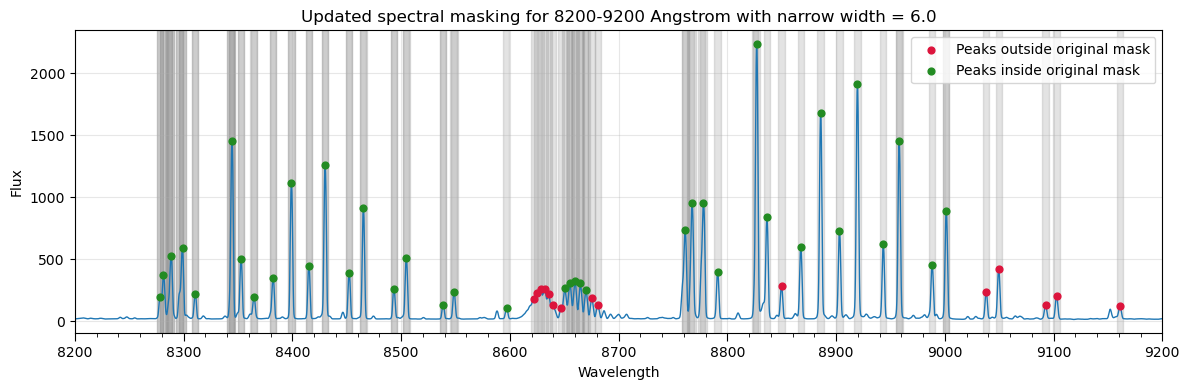

In [14]:
peak_wave_min = 8200.0
peak_wave_max = 9200.0
peak_flux_min = 100.0
updated_narrow_width = 6.0
special_center = 7628.0
special_original_width = 84.0
special_updated_width = 96.0

peak_window = (
    np.isfinite(wave_f)
    & np.isfinite(flux_f)
    & (wave_f >= peak_wave_min)
    & (wave_f <= peak_wave_max)
)

wave_peak = wave_f[peak_window]
flux_peak = flux_f[peak_window]

if wave_peak.size < 3:
    raise ValueError("Not enough samples to detect peaks in the selected wavelength range.")

interior = np.arange(1, flux_peak.size - 1)
peak_mask = (
    (flux_peak[1:-1] >= peak_flux_min)
    & (flux_peak[1:-1] > flux_peak[:-2])
    & (flux_peak[1:-1] >= flux_peak[2:])
)
peak_indices = interior[peak_mask]
peak_wavelengths = wave_peak[peak_indices]
peak_fluxes = flux_peak[peak_indices]

sort_order = np.argsort(peak_wavelengths)
peak_wavelengths = peak_wavelengths[sort_order]
peak_fluxes = peak_fluxes[sort_order]

peak_in_mask = np.array([
    any(left_edge <= wavelength <= right_edge for left_edge, right_edge, _, _ in sky_masks)
    for wavelength in peak_wavelengths
])

def update_existing_mask(mask_entry):
    left_edge, right_edge, center, width = mask_entry
    updated_width = width

    if np.isclose(center, special_center, atol=0.5) and np.isclose(width, special_original_width, atol=0.5):
        updated_width = special_updated_width
    elif np.isclose(width, 5.0, atol=1e-6):
        updated_width = updated_narrow_width

    half_width = updated_width / 2.0
    return (center - half_width, center + half_width, center, updated_width)

existing_masks_in_range = [
    update_existing_mask(mask_entry)
    for mask_entry in sky_masks
    if mask_entry[1] >= peak_wave_min and mask_entry[0] <= peak_wave_max
]

new_red_masks = []
for wavelength in peak_wavelengths[~peak_in_mask]:
    half_width = updated_narrow_width / 2.0
    new_red_masks.append((wavelength - half_width, wavelength + half_width, wavelength, updated_narrow_width))

updated_masks = sorted(existing_masks_in_range + new_red_masks, key=lambda mask_entry: mask_entry[2])

print(
    f"Detected peaks for {peak_wave_min:.0f}-{peak_wave_max:.0f} Angstrom "
    f"and flux >= {peak_flux_min:.0f}: {peak_wavelengths.size}"
)
print(f"Peaks already masked by specMask_KIN: {np.count_nonzero(peak_in_mask)}")
print(f"Peaks not yet masked: {np.count_nonzero(~peak_in_mask)}")
print(f"Existing sky masks in range after width updates: {len(existing_masks_in_range)}")
print(f"New masks added from red peaks: {len(new_red_masks)}")
print(f"Total updated masks in range: {len(updated_masks)}")

if peak_wavelengths.size == 0:
    print("No peaks satisfy the selection criteria.")
else:
    strongest_index = np.argmax(peak_fluxes)
    print(
        f"Strongest peak: wavelength = {peak_wavelengths[strongest_index]:.2f} Angstrom, "
        f"flux = {peak_fluxes[strongest_index]:.2f}"
    )

    if new_red_masks:
        print("\nNew mask centers from red peaks:")
        for _, _, wavelength, width in new_red_masks:
            print(f"{wavelength:9.2f}  width={width:.2f}")

fig, ax = plt.subplots(figsize=(12, 4))
add_sky_mask_bands(ax, updated_masks, wave_peak)
ax.plot(wave_peak, flux_peak, lw=1, color="tab:blue")
if peak_wavelengths.size > 0:
    if np.any(~peak_in_mask):
        ax.scatter(
            peak_wavelengths[~peak_in_mask],
            peak_fluxes[~peak_in_mask],
            color="crimson",
            s=24,
            zorder=3,
            label="Peaks outside original mask",
        )
    if np.any(peak_in_mask):
        ax.scatter(
            peak_wavelengths[peak_in_mask],
            peak_fluxes[peak_in_mask],
            color="forestgreen",
            s=24,
            zorder=3,
            label="Peaks inside original mask",
        )
    ax.legend()
ax.set_xlim(peak_wave_min, peak_wave_max)
ax.set_title(f"Updated spectral masking for 8200-9200 Angstrom with narrow width = {updated_narrow_width}")
ax.set_xlabel("Wavelength")
ax.set_ylabel("Flux")
configure_wavelength_ticks(ax, peak_wave_min, peak_wave_max)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [15]:
source_mask_path = Path.cwd() / "specMask_KIN"
output_mask_path = Path.cwd() / "specMask_KIN_narrow6"

peak_wave_min = 6800.0
peak_wave_max = 9200.0
peak_flux_min = 100.0
updated_narrow_width = 6.0
special_center = 7628.0
special_original_width = 84.0
special_updated_width = 96.0
manual_line_width = 20.0
manual_emission_lines = [
    ("OII", 7318.92),
    ("OII", 7319.99),
    ("OII", 7329.67),
    ("OII", 7330.73),
    ("HPa11", 8862.89),
    ("HPa10", 9015.3),
    ("SIII", 9068.6),
]
manual_sky_regions = [
    (7220.0, 40.0),
]

peak_window = (
    np.isfinite(wave_f)
    & np.isfinite(flux_f)
    & (wave_f >= peak_wave_min)
    & (wave_f <= peak_wave_max)
)

wave_peak = wave_f[peak_window]
flux_peak = flux_f[peak_window]

if wave_peak.size < 3:
    raise ValueError("Not enough samples to detect peaks in the selected wavelength range.")

interior = np.arange(1, flux_peak.size - 1)
peak_mask = (
    (flux_peak[1:-1] >= peak_flux_min)
    & (flux_peak[1:-1] > flux_peak[:-2])
    & (flux_peak[1:-1] >= flux_peak[2:])
)
peak_indices = interior[peak_mask]
peak_wavelengths = wave_peak[peak_indices]
peak_fluxes = flux_peak[peak_indices]

sort_order = np.argsort(peak_wavelengths)
peak_wavelengths = peak_wavelengths[sort_order]
peak_fluxes = peak_fluxes[sort_order]

peak_in_mask = np.array([
    any(left_edge <= wavelength <= right_edge for left_edge, right_edge, _, _ in sky_masks)
    for wavelength in peak_wavelengths
])
new_red_centers = peak_wavelengths[~peak_in_mask]

if not source_mask_path.exists():
    raise FileNotFoundError(f"Source mask file not found: {source_mask_path}")

original_lines = source_mask_path.read_text().splitlines()
updated_lines = []
updated_existing_sky_count = 0

for raw_line in original_lines:
    stripped = raw_line.strip()
    if not stripped or stripped.startswith("#"):
        updated_lines.append(raw_line)
        continue

    parts = stripped.split()
    if len(parts) < 3:
        updated_lines.append(raw_line)
        continue

    try:
        center = float(parts[0])
        width = float(parts[1])
    except ValueError:
        updated_lines.append(raw_line)
        continue

    comment = " ".join(parts[2:])
    comment_lower = comment.lower()

    if comment_lower == "sky":
        updated_width = width
        if np.isclose(center, special_center, atol=0.5) and np.isclose(width, special_original_width, atol=0.5):
            updated_width = special_updated_width
        elif np.isclose(width, 5.0, atol=1e-6):
            updated_width = updated_narrow_width

        updated_lines.append(f"{center:<20.12f} {updated_width:<10.2f} {comment}")
        updated_existing_sky_count += 1
    else:
        updated_lines.append(raw_line)

updated_lines.append("")
updated_lines.append("# Added skyline masks from detected peaks that were outside the original sky masks")
for wavelength in new_red_centers:
    updated_lines.append(f"{wavelength:<20.12f} {updated_narrow_width:<10.2f} sky")

updated_lines.append("")
updated_lines.append("# Added manual sky-region masks")
for region_center, region_width in manual_sky_regions:
    updated_lines.append(f"{region_center:<20.12f} {region_width:<10.2f} sky")

updated_lines.append("")
updated_lines.append("# Added fitting emission-line masks")
for comment, wavelength in manual_emission_lines:
    updated_lines.append(f"{wavelength:<20.12f} {manual_line_width:<10.2f} {comment}")

output_mask_path.write_text("\n".join(updated_lines) + "\n")

print(f"Source mask file: {source_mask_path}")
print(f"Output mask file: {output_mask_path}")
print(f"Updated existing sky-mask rows: {updated_existing_sky_count}")
print(f"Added new sky-mask rows: {new_red_centers.size}")
print(f"Added manual sky-region rows: {len(manual_sky_regions)}")
print(f"Added fitting emission-line rows: {len(manual_emission_lines)}")
print(f"Total written lines: {len(updated_lines)}")

Source mask file: /Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/specMask_KIN
Output mask file: /Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/specMask_KIN_narrow6
Updated existing sky-mask rows: 191
Added new sky-mask rows: 22
Added manual sky-region rows: 1
Added fitting emission-line rows: 7
Total written lines: 264


Peak labels determined from original mask: /Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/specMask_KIN
Shaded mask file used for plotting: /Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/specMask_KIN_narrow6
Detected peaks for 6800-9200 Angstrom and flux >= 100: 111
Peaks inside original specMask_KIN: 89
Peaks outside original specMask_KIN: 22
specMask_KIN_narrow6 bands in 6800-9200 Angstrom: 209


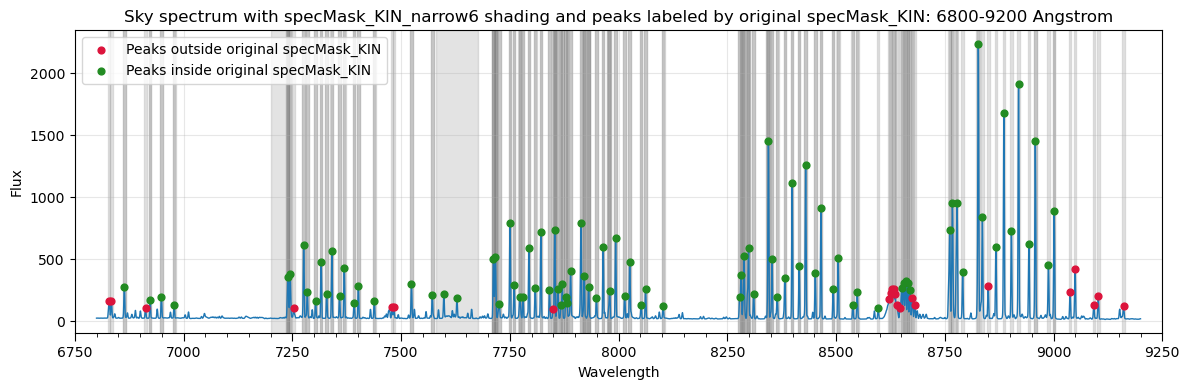

In [16]:
updated_mask_path = Path.cwd() / "specMask_KIN_narrow6"
updated_sky_masks = load_sky_masks(updated_mask_path)

peak_wave_min = 6800.0
peak_wave_max = 9200.0
peak_flux_min = 100.0

if not updated_mask_path.exists():
    raise FileNotFoundError(f"Updated mask file not found: {updated_mask_path}")

peak_window = (
    np.isfinite(wave_f)
    & np.isfinite(flux_f)
    & (wave_f >= peak_wave_min)
    & (wave_f <= peak_wave_max)
)

wave_peak = wave_f[peak_window]
flux_peak = flux_f[peak_window]

if wave_peak.size < 3:
    raise ValueError("Not enough samples to detect peaks in the selected wavelength range.")

interior = np.arange(1, flux_peak.size - 1)
peak_mask = (
    (flux_peak[1:-1] >= peak_flux_min)
    & (flux_peak[1:-1] > flux_peak[:-2])
    & (flux_peak[1:-1] >= flux_peak[2:])
)
peak_indices = interior[peak_mask]
peak_wavelengths = wave_peak[peak_indices]
peak_fluxes = flux_peak[peak_indices]

sort_order = np.argsort(peak_wavelengths)
peak_wavelengths = peak_wavelengths[sort_order]
peak_fluxes = peak_fluxes[sort_order]

peak_in_original_mask = np.array([
    any(left_edge <= wavelength <= right_edge for left_edge, right_edge, _, _ in sky_masks)
    for wavelength in peak_wavelengths
])

print(f"Peak labels determined from original mask: {mask_path}")
print(f"Shaded mask file used for plotting: {updated_mask_path}")
print(
    f"Detected peaks for {peak_wave_min:.0f}-{peak_wave_max:.0f} Angstrom "
    f"and flux >= {peak_flux_min:.0f}: {peak_wavelengths.size}"
)
print(f"Peaks inside original specMask_KIN: {np.count_nonzero(peak_in_original_mask)}")
print(f"Peaks outside original specMask_KIN: {np.count_nonzero(~peak_in_original_mask)}")

fig, ax = plt.subplots(figsize=(12, 4))
visible_updated_masks = add_sky_mask_bands(ax, updated_sky_masks, wave_peak)
ax.plot(wave_peak, flux_peak, lw=1, color="tab:blue")
if peak_wavelengths.size > 0:
    if np.any(~peak_in_original_mask):
        ax.scatter(
            peak_wavelengths[~peak_in_original_mask],
            peak_fluxes[~peak_in_original_mask],
            color="crimson",
            s=24,
            zorder=3,
            label="Peaks outside original specMask_KIN",
        )
    if np.any(peak_in_original_mask):
        ax.scatter(
            peak_wavelengths[peak_in_original_mask],
            peak_fluxes[peak_in_original_mask],
            color="forestgreen",
            s=24,
            zorder=3,
            label="Peaks inside original specMask_KIN",
        )
    ax.legend()
ax.set_xlim(peak_wave_min, peak_wave_max)
ax.set_title("Sky spectrum with specMask_KIN_narrow6 shading and peaks labeled by original specMask_KIN: 6800-9200 Angstrom")
ax.set_xlabel("Wavelength")
ax.set_ylabel("Flux")
configure_wavelength_ticks(ax, peak_wave_min, peak_wave_max)
ax.grid(alpha=0.3)
print(f"specMask_KIN_narrow6 bands in 6800-9200 Angstrom: {visible_updated_masks}")
fig.tight_layout()
plt.show()

## Try $7\AA$

Detected peaks for 6800-9200 Angstrom and flux >= 100: 111
Peaks already masked by specMask_KIN: 89
Peaks not yet masked: 22
Existing sky masks in range after width updates: 186
New masks added from red peaks: 22
Total updated masks in range: 208
Strongest peak: wavelength = 8827.19 Angstrom, flux = 2235.55

New mask centers from red peaks:
  6829.06  width=7.00
  6834.38  width=7.00
  6912.81  width=7.00
  7253.12  width=7.00
  7479.69  width=7.00
  7483.44  width=7.00
  7850.00  width=7.00
  8622.19  width=7.00
  8625.31  width=7.00
  8628.75  width=7.00
  8632.19  width=7.00
  8635.94  width=7.00
  8639.69  width=7.00
  8647.19  width=7.00
  8675.31  width=7.00
  8680.94  width=7.00
  8850.00  width=7.00
  9038.12  width=7.00
  9049.69  width=7.00
  9092.81  width=7.00
  9102.81  width=7.00
  9161.25  width=7.00


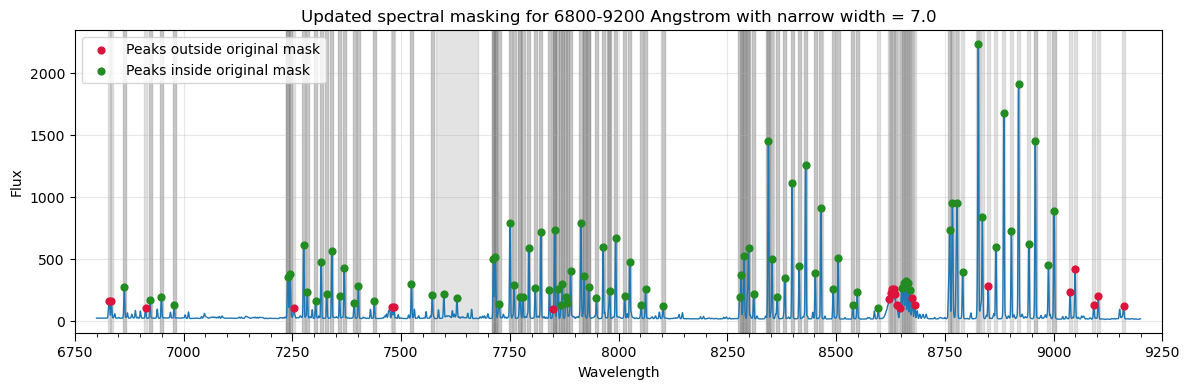

In [17]:
peak_wave_min = 6800.0
peak_wave_max = 9200.0
peak_flux_min = 100.0
updated_narrow_width = 7.0
special_center = 7628.0
special_original_width = 84.0
special_updated_width = 96.0

peak_window = (
    np.isfinite(wave_f)
    & np.isfinite(flux_f)
    & (wave_f >= peak_wave_min)
    & (wave_f <= peak_wave_max)
)

wave_peak = wave_f[peak_window]
flux_peak = flux_f[peak_window]

if wave_peak.size < 3:
    raise ValueError("Not enough samples to detect peaks in the selected wavelength range.")

interior = np.arange(1, flux_peak.size - 1)
peak_mask = (
    (flux_peak[1:-1] >= peak_flux_min)
    & (flux_peak[1:-1] > flux_peak[:-2])
    & (flux_peak[1:-1] >= flux_peak[2:])
)
peak_indices = interior[peak_mask]
peak_wavelengths = wave_peak[peak_indices]
peak_fluxes = flux_peak[peak_indices]

sort_order = np.argsort(peak_wavelengths)
peak_wavelengths = peak_wavelengths[sort_order]
peak_fluxes = peak_fluxes[sort_order]

peak_in_mask = np.array([
    any(left_edge <= wavelength <= right_edge for left_edge, right_edge, _, _ in sky_masks)
    for wavelength in peak_wavelengths
])

def update_existing_mask(mask_entry):
    left_edge, right_edge, center, width = mask_entry
    updated_width = width

    if np.isclose(center, special_center, atol=0.5) and np.isclose(width, special_original_width, atol=0.5):
        updated_width = special_updated_width
    elif np.isclose(width, 5.0, atol=1e-6):
        updated_width = updated_narrow_width

    half_width = updated_width / 2.0
    return (center - half_width, center + half_width, center, updated_width)

existing_masks_in_range = [
    update_existing_mask(mask_entry)
    for mask_entry in sky_masks
    if mask_entry[1] >= peak_wave_min and mask_entry[0] <= peak_wave_max
]

new_red_masks = []
for wavelength in peak_wavelengths[~peak_in_mask]:
    half_width = updated_narrow_width / 2.0
    new_red_masks.append((wavelength - half_width, wavelength + half_width, wavelength, updated_narrow_width))

updated_masks = sorted(existing_masks_in_range + new_red_masks, key=lambda mask_entry: mask_entry[2])

print(
    f"Detected peaks for {peak_wave_min:.0f}-{peak_wave_max:.0f} Angstrom "
    f"and flux >= {peak_flux_min:.0f}: {peak_wavelengths.size}"
)
print(f"Peaks already masked by specMask_KIN: {np.count_nonzero(peak_in_mask)}")
print(f"Peaks not yet masked: {np.count_nonzero(~peak_in_mask)}")
print(f"Existing sky masks in range after width updates: {len(existing_masks_in_range)}")
print(f"New masks added from red peaks: {len(new_red_masks)}")
print(f"Total updated masks in range: {len(updated_masks)}")

if peak_wavelengths.size == 0:
    print("No peaks satisfy the selection criteria.")
else:
    strongest_index = np.argmax(peak_fluxes)
    print(
        f"Strongest peak: wavelength = {peak_wavelengths[strongest_index]:.2f} Angstrom, "
        f"flux = {peak_fluxes[strongest_index]:.2f}"
    )

    if new_red_masks:
        print("\nNew mask centers from red peaks:")
        for _, _, wavelength, width in new_red_masks:
            print(f"{wavelength:9.2f}  width={width:.2f}")

fig, ax = plt.subplots(figsize=(12, 4))
add_sky_mask_bands(ax, updated_masks, wave_peak)
ax.plot(wave_peak, flux_peak, lw=1, color="tab:blue")
if peak_wavelengths.size > 0:
    if np.any(~peak_in_mask):
        ax.scatter(
            peak_wavelengths[~peak_in_mask],
            peak_fluxes[~peak_in_mask],
            color="crimson",
            s=24,
            zorder=3,
            label="Peaks outside original mask",
        )
    if np.any(peak_in_mask):
        ax.scatter(
            peak_wavelengths[peak_in_mask],
            peak_fluxes[peak_in_mask],
            color="forestgreen",
            s=24,
            zorder=3,
            label="Peaks inside original mask",
        )
    ax.legend()
ax.set_xlim(peak_wave_min, peak_wave_max)
ax.set_title(f"Updated spectral masking for 6800-9200 Angstrom with narrow width = {updated_narrow_width}")
ax.set_xlabel("Wavelength")
ax.set_ylabel("Flux")
configure_wavelength_ticks(ax, peak_wave_min, peak_wave_max)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

Detected peaks for 6800-7200 Angstrom and flux >= 100: 7
Peaks already masked by specMask_KIN: 4
Peaks not yet masked: 3
Existing sky masks in range after width updates: 8
New masks added from red peaks: 3
Total updated masks in range: 11
Strongest peak: wavelength = 6863.75 Angstrom, flux = 278.61

New mask centers from red peaks:
  6829.06  width=7.00
  6834.38  width=7.00
  6912.81  width=7.00


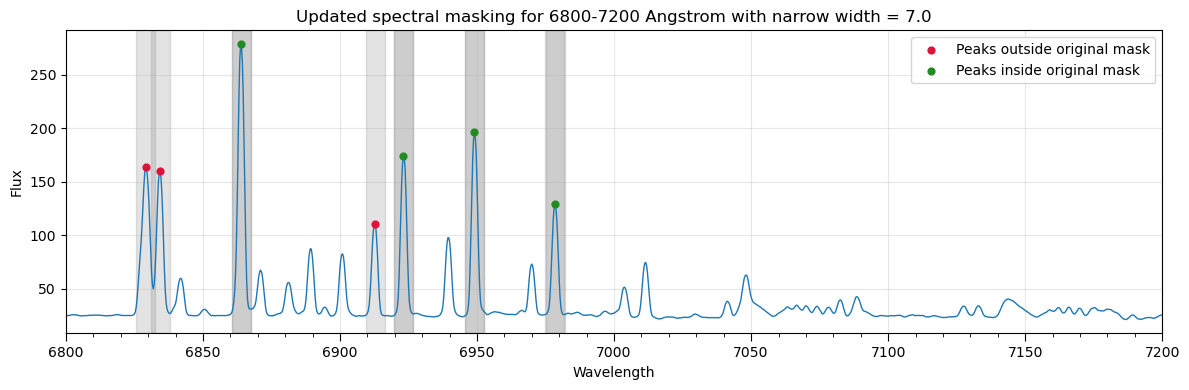

In [18]:
peak_wave_min = 6800.0
peak_wave_max = 7200.0
peak_flux_min = 100.0
updated_narrow_width = 7.0
special_center = 7628.0
special_original_width = 84.0
special_updated_width = 96.0

peak_window = (
    np.isfinite(wave_f)
    & np.isfinite(flux_f)
    & (wave_f >= peak_wave_min)
    & (wave_f <= peak_wave_max)
)

wave_peak = wave_f[peak_window]
flux_peak = flux_f[peak_window]

if wave_peak.size < 3:
    raise ValueError("Not enough samples to detect peaks in the selected wavelength range.")

interior = np.arange(1, flux_peak.size - 1)
peak_mask = (
    (flux_peak[1:-1] >= peak_flux_min)
    & (flux_peak[1:-1] > flux_peak[:-2])
    & (flux_peak[1:-1] >= flux_peak[2:])
)
peak_indices = interior[peak_mask]
peak_wavelengths = wave_peak[peak_indices]
peak_fluxes = flux_peak[peak_indices]

sort_order = np.argsort(peak_wavelengths)
peak_wavelengths = peak_wavelengths[sort_order]
peak_fluxes = peak_fluxes[sort_order]

peak_in_mask = np.array([
    any(left_edge <= wavelength <= right_edge for left_edge, right_edge, _, _ in sky_masks)
    for wavelength in peak_wavelengths
])

def update_existing_mask(mask_entry):
    left_edge, right_edge, center, width = mask_entry
    updated_width = width

    if np.isclose(center, special_center, atol=0.5) and np.isclose(width, special_original_width, atol=0.5):
        updated_width = special_updated_width
    elif np.isclose(width, 5.0, atol=1e-6):
        updated_width = updated_narrow_width

    half_width = updated_width / 2.0
    return (center - half_width, center + half_width, center, updated_width)

existing_masks_in_range = [
    update_existing_mask(mask_entry)
    for mask_entry in sky_masks
    if mask_entry[1] >= peak_wave_min and mask_entry[0] <= peak_wave_max
]

new_red_masks = []
for wavelength in peak_wavelengths[~peak_in_mask]:
    half_width = updated_narrow_width / 2.0
    new_red_masks.append((wavelength - half_width, wavelength + half_width, wavelength, updated_narrow_width))

updated_masks = sorted(existing_masks_in_range + new_red_masks, key=lambda mask_entry: mask_entry[2])

print(
    f"Detected peaks for {peak_wave_min:.0f}-{peak_wave_max:.0f} Angstrom "
    f"and flux >= {peak_flux_min:.0f}: {peak_wavelengths.size}"
)
print(f"Peaks already masked by specMask_KIN: {np.count_nonzero(peak_in_mask)}")
print(f"Peaks not yet masked: {np.count_nonzero(~peak_in_mask)}")
print(f"Existing sky masks in range after width updates: {len(existing_masks_in_range)}")
print(f"New masks added from red peaks: {len(new_red_masks)}")
print(f"Total updated masks in range: {len(updated_masks)}")

if peak_wavelengths.size == 0:
    print("No peaks satisfy the selection criteria.")
else:
    strongest_index = np.argmax(peak_fluxes)
    print(
        f"Strongest peak: wavelength = {peak_wavelengths[strongest_index]:.2f} Angstrom, "
        f"flux = {peak_fluxes[strongest_index]:.2f}"
    )

    if new_red_masks:
        print("\nNew mask centers from red peaks:")
        for _, _, wavelength, width in new_red_masks:
            print(f"{wavelength:9.2f}  width={width:.2f}")

fig, ax = plt.subplots(figsize=(12, 4))
add_sky_mask_bands(ax, updated_masks, wave_peak)
ax.plot(wave_peak, flux_peak, lw=1, color="tab:blue")
if peak_wavelengths.size > 0:
    if np.any(~peak_in_mask):
        ax.scatter(
            peak_wavelengths[~peak_in_mask],
            peak_fluxes[~peak_in_mask],
            color="crimson",
            s=24,
            zorder=3,
            label="Peaks outside original mask",
        )
    if np.any(peak_in_mask):
        ax.scatter(
            peak_wavelengths[peak_in_mask],
            peak_fluxes[peak_in_mask],
            color="forestgreen",
            s=24,
            zorder=3,
            label="Peaks inside original mask",
        )
    ax.legend()
ax.set_xlim(peak_wave_min, peak_wave_max)
ax.set_title(f"Updated spectral masking for 6800-7200 Angstrom with narrow width = {updated_narrow_width}")
ax.set_xlabel("Wavelength")
ax.set_ylabel("Flux")
configure_wavelength_ticks(ax, peak_wave_min, peak_wave_max)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [19]:
source_mask_path = Path.cwd() / "specMask_KIN"
output_mask_path = Path.cwd() / "specMask_KIN_narrow7"

peak_wave_min = 6800.0
peak_wave_max = 9200.0
peak_flux_min = 100.0
updated_narrow_width = 7.0
special_center = 7628.0
special_original_width = 84.0
special_updated_width = 96.0
manual_line_width = 20.0
manual_emission_lines = [
    ("OII", 7318.92),
    ("OII", 7319.99),
    ("OII", 7329.67),
    ("OII", 7330.73),
    ("HPa11", 8862.89),
    ("HPa10", 9015.3),
    ("SIII", 9068.6),
]
manual_sky_regions = [
    (7220.0, 40.0),
]

peak_window = (
    np.isfinite(wave_f)
    & np.isfinite(flux_f)
    & (wave_f >= peak_wave_min)
    & (wave_f <= peak_wave_max)
)

wave_peak = wave_f[peak_window]
flux_peak = flux_f[peak_window]

if wave_peak.size < 3:
    raise ValueError("Not enough samples to detect peaks in the selected wavelength range.")

interior = np.arange(1, flux_peak.size - 1)
peak_mask = (
    (flux_peak[1:-1] >= peak_flux_min)
    & (flux_peak[1:-1] > flux_peak[:-2])
    & (flux_peak[1:-1] >= flux_peak[2:])
)
peak_indices = interior[peak_mask]
peak_wavelengths = wave_peak[peak_indices]
peak_fluxes = flux_peak[peak_indices]

sort_order = np.argsort(peak_wavelengths)
peak_wavelengths = peak_wavelengths[sort_order]
peak_fluxes = peak_fluxes[sort_order]

peak_in_mask = np.array([
    any(left_edge <= wavelength <= right_edge for left_edge, right_edge, _, _ in sky_masks)
    for wavelength in peak_wavelengths
])
new_red_centers = peak_wavelengths[~peak_in_mask]

if not source_mask_path.exists():
    raise FileNotFoundError(f"Source mask file not found: {source_mask_path}")

original_lines = source_mask_path.read_text().splitlines()
updated_lines = []
updated_existing_sky_count = 0

for raw_line in original_lines:
    stripped = raw_line.strip()
    if not stripped or stripped.startswith("#"):
        updated_lines.append(raw_line)
        continue

    parts = stripped.split()
    if len(parts) < 3:
        updated_lines.append(raw_line)
        continue

    try:
        center = float(parts[0])
        width = float(parts[1])
    except ValueError:
        updated_lines.append(raw_line)
        continue

    comment = " ".join(parts[2:])
    comment_lower = comment.lower()

    if comment_lower == "sky":
        updated_width = width
        if np.isclose(center, special_center, atol=0.5) and np.isclose(width, special_original_width, atol=0.5):
            updated_width = special_updated_width
        elif np.isclose(width, 5.0, atol=1e-6):
            updated_width = updated_narrow_width

        updated_lines.append(f"{center:<20.12f} {updated_width:<10.2f} {comment}")
        updated_existing_sky_count += 1
    else:
        updated_lines.append(raw_line)

updated_lines.append("")
updated_lines.append("# Added skyline masks from detected peaks that were outside the original sky masks")
for wavelength in new_red_centers:
    updated_lines.append(f"{wavelength:<20.12f} {updated_narrow_width:<10.2f} sky")

updated_lines.append("")
updated_lines.append("# Added manual sky-region masks")
for region_center, region_width in manual_sky_regions:
    updated_lines.append(f"{region_center:<20.12f} {region_width:<10.2f} sky")

updated_lines.append("")
updated_lines.append("# Added fitting emission-line masks")
for comment, wavelength in manual_emission_lines:
    updated_lines.append(f"{wavelength:<20.12f} {manual_line_width:<10.2f} {comment}")

output_mask_path.write_text("\n".join(updated_lines) + "\n")

print(f"Source mask file: {source_mask_path}")
print(f"Output mask file: {output_mask_path}")
print(f"Updated existing sky-mask rows: {updated_existing_sky_count}")
print(f"Added new sky-mask rows: {new_red_centers.size}")
print(f"Added manual sky-region rows: {len(manual_sky_regions)}")
print(f"Added fitting emission-line rows: {len(manual_emission_lines)}")
print(f"Total written lines: {len(updated_lines)}")

Source mask file: /Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/specMask_KIN
Output mask file: /Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/specMask_KIN_narrow7
Updated existing sky-mask rows: 191
Added new sky-mask rows: 22
Added manual sky-region rows: 1
Added fitting emission-line rows: 7
Total written lines: 264


Peak labels determined from original mask: /Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/specMask_KIN
Shaded mask file used for plotting: /Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/specMask_KIN_narrow7
Detected peaks for 6800-9200 Angstrom and flux >= 100: 111
Peaks inside original specMask_KIN: 89
Peaks outside original specMask_KIN: 22
specMask_KIN_narrow7 bands in 6800-9200 Angstrom: 209


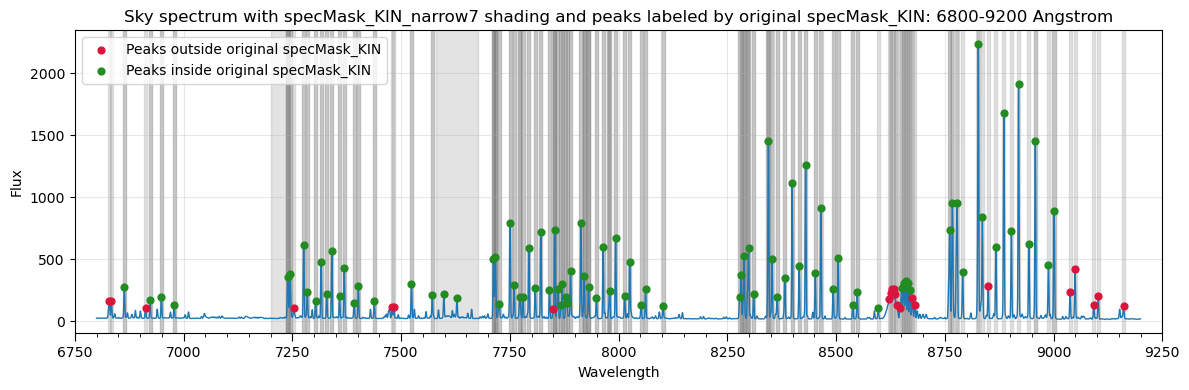

In [20]:
updated_mask_path = Path.cwd() / "specMask_KIN_narrow7"
updated_sky_masks = load_sky_masks(updated_mask_path)

peak_wave_min = 6800.0
peak_wave_max = 9200.0
peak_flux_min = 100.0

if not updated_mask_path.exists():
    raise FileNotFoundError(f"Updated mask file not found: {updated_mask_path}")

peak_window = (
    np.isfinite(wave_f)
    & np.isfinite(flux_f)
    & (wave_f >= peak_wave_min)
    & (wave_f <= peak_wave_max)
)

wave_peak = wave_f[peak_window]
flux_peak = flux_f[peak_window]

if wave_peak.size < 3:
    raise ValueError("Not enough samples to detect peaks in the selected wavelength range.")

interior = np.arange(1, flux_peak.size - 1)
peak_mask = (
    (flux_peak[1:-1] >= peak_flux_min)
    & (flux_peak[1:-1] > flux_peak[:-2])
    & (flux_peak[1:-1] >= flux_peak[2:])
)
peak_indices = interior[peak_mask]
peak_wavelengths = wave_peak[peak_indices]
peak_fluxes = flux_peak[peak_indices]

sort_order = np.argsort(peak_wavelengths)
peak_wavelengths = peak_wavelengths[sort_order]
peak_fluxes = peak_fluxes[sort_order]

peak_in_original_mask = np.array([
    any(left_edge <= wavelength <= right_edge for left_edge, right_edge, _, _ in sky_masks)
    for wavelength in peak_wavelengths
])

print(f"Peak labels determined from original mask: {mask_path}")
print(f"Shaded mask file used for plotting: {updated_mask_path}")
print(
    f"Detected peaks for {peak_wave_min:.0f}-{peak_wave_max:.0f} Angstrom "
    f"and flux >= {peak_flux_min:.0f}: {peak_wavelengths.size}"
)
print(f"Peaks inside original specMask_KIN: {np.count_nonzero(peak_in_original_mask)}")
print(f"Peaks outside original specMask_KIN: {np.count_nonzero(~peak_in_original_mask)}")

fig, ax = plt.subplots(figsize=(12, 4))
visible_updated_masks = add_sky_mask_bands(ax, updated_sky_masks, wave_peak)
ax.plot(wave_peak, flux_peak, lw=1, color="tab:blue")
if peak_wavelengths.size > 0:
    if np.any(~peak_in_original_mask):
        ax.scatter(
            peak_wavelengths[~peak_in_original_mask],
            peak_fluxes[~peak_in_original_mask],
            color="crimson",
            s=24,
            zorder=3,
            label="Peaks outside original specMask_KIN",
        )
    if np.any(peak_in_original_mask):
        ax.scatter(
            peak_wavelengths[peak_in_original_mask],
            peak_fluxes[peak_in_original_mask],
            color="forestgreen",
            s=24,
            zorder=3,
            label="Peaks inside original specMask_KIN",
        )
    ax.legend()
ax.set_xlim(peak_wave_min, peak_wave_max)
ax.set_title(
    "Sky spectrum with specMask_KIN_narrow7 shading and peaks labeled by original specMask_KIN: "
    "6800-9200 Angstrom"
)
ax.set_xlabel("Wavelength")
ax.set_ylabel("Flux")
configure_wavelength_ticks(ax, peak_wave_min, peak_wave_max)
ax.grid(alpha=0.3)
print(f"specMask_KIN_narrow7 bands in 6800-9200 Angstrom: {visible_updated_masks}")
fig.tight_layout()
plt.show()

## Try $8\AA$

In [21]:
source_mask_path = Path.cwd() / "specMask_KIN"
output_mask_path = Path.cwd() / "specMask_KIN_narrow8"

peak_wave_min = 6800.0
peak_wave_max = 9200.0
peak_flux_min = 100.0
updated_narrow_width = 8.0
special_center = 7628.0
special_original_width = 84.0
special_updated_width = 96.0
manual_line_width = 20.0
manual_emission_lines = [
    ("OII", 7318.92),
    ("OII", 7319.99),
    ("OII", 7329.67),
    ("OII", 7330.73),
    ("HPa11", 8862.89),
    ("HPa10", 9015.3),
    ("SIII", 9068.6),
]
manual_sky_regions = [
    (7220.0, 40.0),
]

peak_window = (
    np.isfinite(wave_f)
    & np.isfinite(flux_f)
    & (wave_f >= peak_wave_min)
    & (wave_f <= peak_wave_max)
)

wave_peak = wave_f[peak_window]
flux_peak = flux_f[peak_window]

if wave_peak.size < 3:
    raise ValueError("Not enough samples to detect peaks in the selected wavelength range.")

interior = np.arange(1, flux_peak.size - 1)
peak_mask = (
    (flux_peak[1:-1] >= peak_flux_min)
    & (flux_peak[1:-1] > flux_peak[:-2])
    & (flux_peak[1:-1] >= flux_peak[2:])
)
peak_indices = interior[peak_mask]
peak_wavelengths = wave_peak[peak_indices]
peak_fluxes = flux_peak[peak_indices]

sort_order = np.argsort(peak_wavelengths)
peak_wavelengths = peak_wavelengths[sort_order]
peak_fluxes = peak_fluxes[sort_order]

peak_in_mask = np.array([
    any(left_edge <= wavelength <= right_edge for left_edge, right_edge, _, _ in sky_masks)
    for wavelength in peak_wavelengths
])
new_red_centers = peak_wavelengths[~peak_in_mask]

if not source_mask_path.exists():
    raise FileNotFoundError(f"Source mask file not found: {source_mask_path}")

original_lines = source_mask_path.read_text().splitlines()
updated_lines = []
updated_existing_sky_count = 0

for raw_line in original_lines:
    stripped = raw_line.strip()
    if not stripped or stripped.startswith("#"):
        updated_lines.append(raw_line)
        continue

    parts = stripped.split()
    if len(parts) < 3:
        updated_lines.append(raw_line)
        continue

    try:
        center = float(parts[0])
        width = float(parts[1])
    except ValueError:
        updated_lines.append(raw_line)
        continue

    comment = " ".join(parts[2:])
    comment_lower = comment.lower()

    if comment_lower == "sky":
        updated_width = width
        if np.isclose(center, special_center, atol=0.5) and np.isclose(width, special_original_width, atol=0.5):
            updated_width = special_updated_width
        elif np.isclose(width, 5.0, atol=1e-6):
            updated_width = updated_narrow_width

        updated_lines.append(f"{center:<20.12f} {updated_width:<10.2f} {comment}")
        updated_existing_sky_count += 1
    else:
        updated_lines.append(raw_line)

updated_lines.append("")
updated_lines.append("# Added skyline masks from detected peaks that were outside the original sky masks")
for wavelength in new_red_centers:
    updated_lines.append(f"{wavelength:<20.12f} {updated_narrow_width:<10.2f} sky")

updated_lines.append("")
updated_lines.append("# Added manual sky-region masks")
for region_center, region_width in manual_sky_regions:
    updated_lines.append(f"{region_center:<20.12f} {region_width:<10.2f} sky")

updated_lines.append("")
updated_lines.append("# Added fitting emission-line masks")
for comment, wavelength in manual_emission_lines:
    updated_lines.append(f"{wavelength:<20.12f} {manual_line_width:<10.2f} {comment}")

output_mask_path.write_text("\n".join(updated_lines) + "\n")

print(f"Source mask file: {source_mask_path}")
print(f"Output mask file: {output_mask_path}")
print(f"Updated existing sky-mask rows: {updated_existing_sky_count}")
print(f"Added new sky-mask rows: {new_red_centers.size}")
print(f"Added manual sky-region rows: {len(manual_sky_regions)}")
print(f"Added fitting emission-line rows: {len(manual_emission_lines)}")
print(f"Total written lines: {len(updated_lines)}")

Source mask file: /Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/specMask_KIN
Output mask file: /Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/specMask_KIN_narrow8
Updated existing sky-mask rows: 191
Added new sky-mask rows: 22
Added manual sky-region rows: 1
Added fitting emission-line rows: 7
Total written lines: 264


Peak labels determined from original mask: /Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/specMask_KIN
Shaded mask file used for plotting: /Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/specMask_KIN_narrow8
Detected peaks for 6800-9200 Angstrom and flux >= 100: 111
Peaks inside original specMask_KIN: 89
Peaks outside original specMask_KIN: 22
specMask_KIN_narrow8 bands in 6800-9200 Angstrom: 209


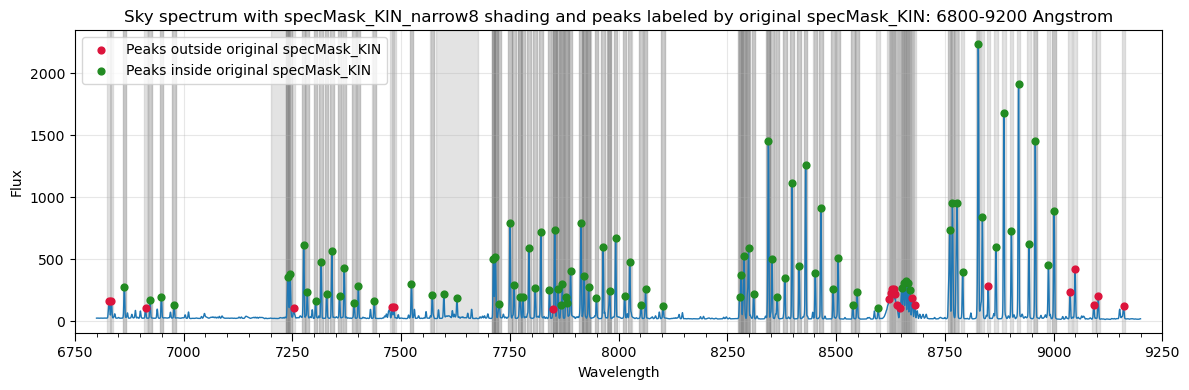

In [22]:
updated_mask_path = Path.cwd() / "specMask_KIN_narrow8"
updated_sky_masks = load_sky_masks(updated_mask_path)

peak_wave_min = 6800.0
peak_wave_max = 9200.0
peak_flux_min = 100.0

if not updated_mask_path.exists():
    raise FileNotFoundError(f"Updated mask file not found: {updated_mask_path}")

peak_window = (
    np.isfinite(wave_f)
    & np.isfinite(flux_f)
    & (wave_f >= peak_wave_min)
    & (wave_f <= peak_wave_max)
)

wave_peak = wave_f[peak_window]
flux_peak = flux_f[peak_window]

if wave_peak.size < 3:
    raise ValueError("Not enough samples to detect peaks in the selected wavelength range.")

interior = np.arange(1, flux_peak.size - 1)
peak_mask = (
    (flux_peak[1:-1] >= peak_flux_min)
    & (flux_peak[1:-1] > flux_peak[:-2])
    & (flux_peak[1:-1] >= flux_peak[2:])
)
peak_indices = interior[peak_mask]
peak_wavelengths = wave_peak[peak_indices]
peak_fluxes = flux_peak[peak_indices]

sort_order = np.argsort(peak_wavelengths)
peak_wavelengths = peak_wavelengths[sort_order]
peak_fluxes = peak_fluxes[sort_order]

peak_in_original_mask = np.array([
    any(left_edge <= wavelength <= right_edge for left_edge, right_edge, _, _ in sky_masks)
    for wavelength in peak_wavelengths
])

print(f"Peak labels determined from original mask: {mask_path}")
print(f"Shaded mask file used for plotting: {updated_mask_path}")
print(
    f"Detected peaks for {peak_wave_min:.0f}-{peak_wave_max:.0f} Angstrom "
    f"and flux >= {peak_flux_min:.0f}: {peak_wavelengths.size}"
)
print(f"Peaks inside original specMask_KIN: {np.count_nonzero(peak_in_original_mask)}")
print(f"Peaks outside original specMask_KIN: {np.count_nonzero(~peak_in_original_mask)}")

fig, ax = plt.subplots(figsize=(12, 4))
visible_updated_masks = add_sky_mask_bands(ax, updated_sky_masks, wave_peak)
ax.plot(wave_peak, flux_peak, lw=1, color="tab:blue")
if peak_wavelengths.size > 0:
    if np.any(~peak_in_original_mask):
        ax.scatter(
            peak_wavelengths[~peak_in_original_mask],
            peak_fluxes[~peak_in_original_mask],
            color="crimson",
            s=24,
            zorder=3,
            label="Peaks outside original specMask_KIN",
        )
    if np.any(peak_in_original_mask):
        ax.scatter(
            peak_wavelengths[peak_in_original_mask],
            peak_fluxes[peak_in_original_mask],
            color="forestgreen",
            s=24,
            zorder=3,
            label="Peaks inside original specMask_KIN",
        )
    ax.legend()
ax.set_xlim(peak_wave_min, peak_wave_max)
ax.set_title(
    "Sky spectrum with specMask_KIN_narrow8 shading and peaks labeled by original specMask_KIN: "
    "6800-9200 Angstrom"
)
ax.set_xlabel("Wavelength")
ax.set_ylabel("Flux")
configure_wavelength_ticks(ax, peak_wave_min, peak_wave_max)
ax.grid(alpha=0.3)
print(f"specMask_KIN_narrow8 bands in 6800-9200 Angstrom: {visible_updated_masks}")
fig.tight_layout()
plt.show()

## Try $10\AA$

In [23]:
source_mask_path = Path.cwd() / "specMask_KIN"
output_mask_path = Path.cwd() / "specMask_KIN_narrow10"

peak_wave_min = 6800.0
peak_wave_max = 9200.0
peak_flux_min = 100.0
updated_narrow_width = 10.0
special_center = 7628.0
special_original_width = 84.0
special_updated_width = 96.0
manual_line_width = 20.0
manual_emission_lines = [
    ("OII", 7318.92),
    ("OII", 7319.99),
    ("OII", 7329.67),
    ("OII", 7330.73),
    ("HPa11", 8862.89),
    ("HPa10", 9015.3),
    ("SIII", 9068.6),
]
manual_sky_regions = [
    (7220.0, 40.0),
]

peak_window = (
    np.isfinite(wave_f)
    & np.isfinite(flux_f)
    & (wave_f >= peak_wave_min)
    & (wave_f <= peak_wave_max)
)

wave_peak = wave_f[peak_window]
flux_peak = flux_f[peak_window]

if wave_peak.size < 3:
    raise ValueError("Not enough samples to detect peaks in the selected wavelength range.")

interior = np.arange(1, flux_peak.size - 1)
peak_mask = (
    (flux_peak[1:-1] >= peak_flux_min)
    & (flux_peak[1:-1] > flux_peak[:-2])
    & (flux_peak[1:-1] >= flux_peak[2:])
)
peak_indices = interior[peak_mask]
peak_wavelengths = wave_peak[peak_indices]
peak_fluxes = flux_peak[peak_indices]

sort_order = np.argsort(peak_wavelengths)
peak_wavelengths = peak_wavelengths[sort_order]
peak_fluxes = peak_fluxes[sort_order]

peak_in_mask = np.array([
    any(left_edge <= wavelength <= right_edge for left_edge, right_edge, _, _ in sky_masks)
    for wavelength in peak_wavelengths
])
new_red_centers = peak_wavelengths[~peak_in_mask]

if not source_mask_path.exists():
    raise FileNotFoundError(f"Source mask file not found: {source_mask_path}")

original_lines = source_mask_path.read_text().splitlines()
updated_lines = []
updated_existing_sky_count = 0

for raw_line in original_lines:
    stripped = raw_line.strip()
    if not stripped or stripped.startswith("#"):
        updated_lines.append(raw_line)
        continue

    parts = stripped.split()
    if len(parts) < 3:
        updated_lines.append(raw_line)
        continue

    try:
        center = float(parts[0])
        width = float(parts[1])
    except ValueError:
        updated_lines.append(raw_line)
        continue

    comment = " ".join(parts[2:])
    comment_lower = comment.lower()

    if comment_lower == "sky":
        updated_width = width
        if np.isclose(center, special_center, atol=0.5) and np.isclose(width, special_original_width, atol=0.5):
            updated_width = special_updated_width
        elif np.isclose(width, 5.0, atol=1e-6):
            updated_width = updated_narrow_width

        updated_lines.append(f"{center:<20.12f} {updated_width:<10.2f} {comment}")
        updated_existing_sky_count += 1
    else:
        updated_lines.append(raw_line)

updated_lines.append("")
updated_lines.append("# Added skyline masks from detected peaks that were outside the original sky masks")
for wavelength in new_red_centers:
    updated_lines.append(f"{wavelength:<20.12f} {updated_narrow_width:<10.2f} sky")

updated_lines.append("")
updated_lines.append("# Added manual sky-region masks")
for region_center, region_width in manual_sky_regions:
    updated_lines.append(f"{region_center:<20.12f} {region_width:<10.2f} sky")

updated_lines.append("")
updated_lines.append("# Added fitting emission-line masks")
for comment, wavelength in manual_emission_lines:
    updated_lines.append(f"{wavelength:<20.12f} {manual_line_width:<10.2f} {comment}")

output_mask_path.write_text("\n".join(updated_lines) + "\n")

print(f"Source mask file: {source_mask_path}")
print(f"Output mask file: {output_mask_path}")
print(f"Updated existing sky-mask rows: {updated_existing_sky_count}")
print(f"Added new sky-mask rows: {new_red_centers.size}")
print(f"Added manual sky-region rows: {len(manual_sky_regions)}")
print(f"Added fitting emission-line rows: {len(manual_emission_lines)}")
print(f"Total written lines: {len(updated_lines)}")

Source mask file: /Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/specMask_KIN
Output mask file: /Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/specMask_KIN_narrow10
Updated existing sky-mask rows: 191
Added new sky-mask rows: 22
Added manual sky-region rows: 1
Added fitting emission-line rows: 7
Total written lines: 264


Peak labels determined from original mask: /Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/specMask_KIN
Shaded mask file used for plotting: /Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/specMask_KIN_narrow10
Detected peaks for 6800-9200 Angstrom and flux >= 100: 111
Peaks inside original specMask_KIN: 89
Peaks outside original specMask_KIN: 22
specMask_KIN_narrow10 bands in 6800-9200 Angstrom: 209


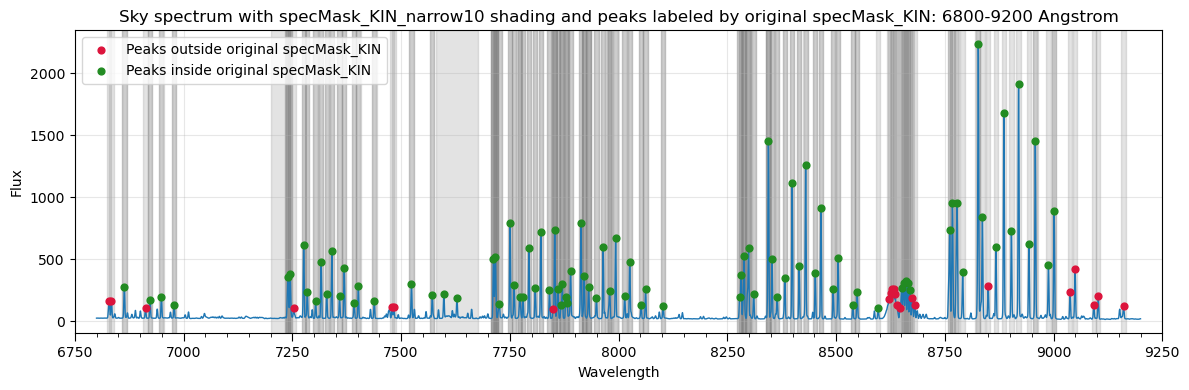

In [24]:
updated_mask_path = Path.cwd() / "specMask_KIN_narrow10"
updated_sky_masks = load_sky_masks(updated_mask_path)

peak_wave_min = 6800.0
peak_wave_max = 9200.0
peak_flux_min = 100.0

if not updated_mask_path.exists():
    raise FileNotFoundError(f"Updated mask file not found: {updated_mask_path}")

peak_window = (
    np.isfinite(wave_f)
    & np.isfinite(flux_f)
    & (wave_f >= peak_wave_min)
    & (wave_f <= peak_wave_max)
)

wave_peak = wave_f[peak_window]
flux_peak = flux_f[peak_window]

if wave_peak.size < 3:
    raise ValueError("Not enough samples to detect peaks in the selected wavelength range.")

interior = np.arange(1, flux_peak.size - 1)
peak_mask = (
    (flux_peak[1:-1] >= peak_flux_min)
    & (flux_peak[1:-1] > flux_peak[:-2])
    & (flux_peak[1:-1] >= flux_peak[2:])
)
peak_indices = interior[peak_mask]
peak_wavelengths = wave_peak[peak_indices]
peak_fluxes = flux_peak[peak_indices]

sort_order = np.argsort(peak_wavelengths)
peak_wavelengths = peak_wavelengths[sort_order]
peak_fluxes = peak_fluxes[sort_order]

peak_in_original_mask = np.array([
    any(left_edge <= wavelength <= right_edge for left_edge, right_edge, _, _ in sky_masks)
    for wavelength in peak_wavelengths
])

print(f"Peak labels determined from original mask: {mask_path}")
print(f"Shaded mask file used for plotting: {updated_mask_path}")
print(
    f"Detected peaks for {peak_wave_min:.0f}-{peak_wave_max:.0f} Angstrom "
    f"and flux >= {peak_flux_min:.0f}: {peak_wavelengths.size}"
)
print(f"Peaks inside original specMask_KIN: {np.count_nonzero(peak_in_original_mask)}")
print(f"Peaks outside original specMask_KIN: {np.count_nonzero(~peak_in_original_mask)}")

fig, ax = plt.subplots(figsize=(12, 4))
visible_updated_masks = add_sky_mask_bands(ax, updated_sky_masks, wave_peak)
ax.plot(wave_peak, flux_peak, lw=1, color="tab:blue")
if peak_wavelengths.size > 0:
    if np.any(~peak_in_original_mask):
        ax.scatter(
            peak_wavelengths[~peak_in_original_mask],
            peak_fluxes[~peak_in_original_mask],
            color="crimson",
            s=24,
            zorder=3,
            label="Peaks outside original specMask_KIN",
        )
    if np.any(peak_in_original_mask):
        ax.scatter(
            peak_wavelengths[peak_in_original_mask],
            peak_fluxes[peak_in_original_mask],
            color="forestgreen",
            s=24,
            zorder=3,
            label="Peaks inside original specMask_KIN",
        )
    ax.legend()
ax.set_xlim(peak_wave_min, peak_wave_max)
ax.set_title(
    "Sky spectrum with specMask_KIN_narrow10 shading and peaks labeled by original specMask_KIN: "
    "6800-9200 Angstrom"
)
ax.set_xlabel("Wavelength")
ax.set_ylabel("Flux")
configure_wavelength_ticks(ax, peak_wave_min, peak_wave_max)
ax.grid(alpha=0.3)
print(f"specMask_KIN_narrow10 bands in 6800-9200 Angstrom: {visible_updated_masks}")
fig.tight_layout()
plt.show()

Peak labels determined from original mask: /Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/specMask_KIN
Shaded mask file used for plotting: /Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/specMask_KIN_narrow10
Detected peaks for 8580-8720 Angstrom and flux >= 100: 15
Peaks inside original specMask_KIN: 6
Peaks outside original specMask_KIN: 9
specMask_KIN_narrow10 bands in 8580-8720 Angstrom: 19


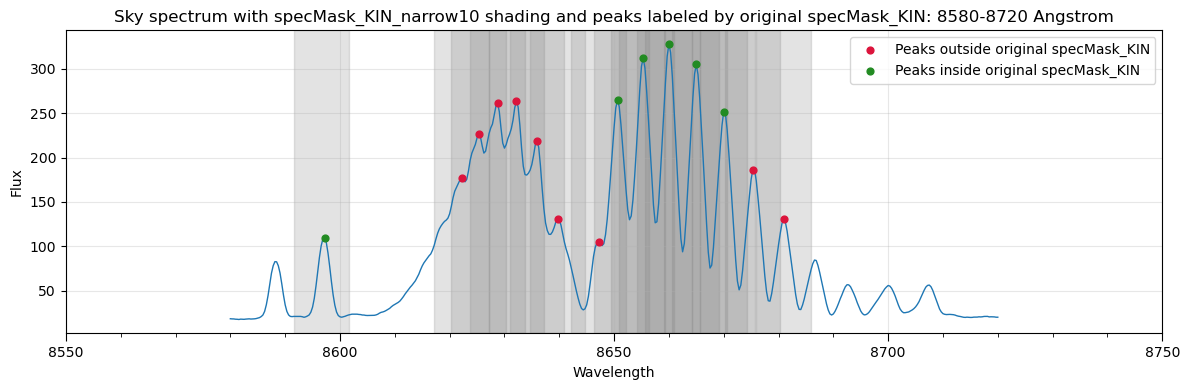

In [25]:
updated_mask_path = Path.cwd() / "specMask_KIN_narrow10"
updated_sky_masks = load_sky_masks(updated_mask_path)

peak_wave_min = 8580.0
peak_wave_max = 8720.0
peak_flux_min = 100.0

if not updated_mask_path.exists():
    raise FileNotFoundError(f"Updated mask file not found: {updated_mask_path}")

peak_window = (
    np.isfinite(wave_f)
    & np.isfinite(flux_f)
    & (wave_f >= peak_wave_min)
    & (wave_f <= peak_wave_max)
)

wave_peak = wave_f[peak_window]
flux_peak = flux_f[peak_window]

if wave_peak.size < 3:
    raise ValueError("Not enough samples to detect peaks in the selected wavelength range.")

interior = np.arange(1, flux_peak.size - 1)
peak_mask = (
    (flux_peak[1:-1] >= peak_flux_min)
    & (flux_peak[1:-1] > flux_peak[:-2])
    & (flux_peak[1:-1] >= flux_peak[2:])
)
peak_indices = interior[peak_mask]
peak_wavelengths = wave_peak[peak_indices]
peak_fluxes = flux_peak[peak_indices]

sort_order = np.argsort(peak_wavelengths)
peak_wavelengths = peak_wavelengths[sort_order]
peak_fluxes = peak_fluxes[sort_order]

peak_in_original_mask = np.array([
    any(left_edge <= wavelength <= right_edge for left_edge, right_edge, _, _ in sky_masks)
    for wavelength in peak_wavelengths
])

print(f"Peak labels determined from original mask: {mask_path}")
print(f"Shaded mask file used for plotting: {updated_mask_path}")
print(
    f"Detected peaks for {peak_wave_min:.0f}-{peak_wave_max:.0f} Angstrom "
    f"and flux >= {peak_flux_min:.0f}: {peak_wavelengths.size}"
)
print(f"Peaks inside original specMask_KIN: {np.count_nonzero(peak_in_original_mask)}")
print(f"Peaks outside original specMask_KIN: {np.count_nonzero(~peak_in_original_mask)}")

fig, ax = plt.subplots(figsize=(12, 4))
visible_updated_masks = add_sky_mask_bands(ax, updated_sky_masks, wave_peak)
ax.plot(wave_peak, flux_peak, lw=1, color="tab:blue")
if peak_wavelengths.size > 0:
    if np.any(~peak_in_original_mask):
        ax.scatter(
            peak_wavelengths[~peak_in_original_mask],
            peak_fluxes[~peak_in_original_mask],
            color="crimson",
            s=24,
            zorder=3,
            label="Peaks outside original specMask_KIN",
        )
    if np.any(peak_in_original_mask):
        ax.scatter(
            peak_wavelengths[peak_in_original_mask],
            peak_fluxes[peak_in_original_mask],
            color="forestgreen",
            s=24,
            zorder=3,
            label="Peaks inside original specMask_KIN",
        )
    ax.legend()
ax.set_xlim(peak_wave_min, peak_wave_max)
ax.set_title(
    "Sky spectrum with specMask_KIN_narrow10 shading and peaks labeled by original specMask_KIN: "
    f"{int(peak_wave_min)}-{int(peak_wave_max)} Angstrom"
)
ax.set_xlabel("Wavelength")
ax.set_ylabel("Flux")
configure_wavelength_ticks(ax, peak_wave_min, peak_wave_max)
ax.grid(alpha=0.3)
print(f"specMask_KIN_narrow10 bands in {int(peak_wave_min)}-{int(peak_wave_max)} Angstrom: {visible_updated_masks}")
fig.tight_layout()
plt.show()